# 03c · Beta & Log-Normal Dağılımları
**Probability Lab** · Continuous Distributions

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Veri biliminin en pratik iki sürekli dağılımını anlayacağız:  
> **Beta** — `[0,1]` aralığında tanımlı; oranlar, olasılıklar ve Bayesian prior için,  
> **Log-Normal** — gerçek hayattaki sağa çarpık verilerin modeli; gelir, fiyat, süre için.  

**Önkoşul:** Normal dağılım ve Z-score (Notebook 03a)  
**Veri:**
- `adult-income.csv` — 32.561 kişilik UCI Adult Census verisi (gelir, meslek, eğitim)
- `commerce-purchase.csv` — 2.6 milyon e-ticaret satın alma kaydı (fiyat)
- `seaborn.diamonds` — Elmas fiyatı (Log-Normal karşılaştırma)
**Araçlar:** Python (scipy, matplotlib, seaborn), R (base), SQL (DuckDB)

---
## 1 · Beta Dağılımı

### 1.1 Sezgi: "Oran Dağılımı"

Normal sorunun cevabı bir sayıdır: "ortalama kaç?"  
Beta sorunun cevabı bir **orandır**: **"başarı oranı kaç?"**

| Senaryo | Beta'nın modellediği şey |
|---|---|
| E-posta kampanyası | Tıklama oranı (CTR) |
|  A/B testi | Conversion rate |
| Bayesian analiz | p parametresinin belirsizliği |
| ML modeli | Sınıflandırma olasılıkları |

### 1.2 PDF ve Parametreler

$X \sim \text{Beta}(\alpha, \beta)$ — tanım kümesi: $x \in [0, 1]$

$$f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)}, \quad 0 \leq x \leq 1$$

$$B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)} \quad \text{(normalleştirici sabit)}$$

$$E[X] = \frac{\alpha}{\alpha + \beta} \qquad \text{Var}(X) = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$$

### 1.3 α ve β Ne Anlama Geliyor?

En güzel sezgi Bayesian yorumdur:

> $\alpha$ = gözlemlenen **başarı** sayısı  
> $\beta$  = gözlemlenen **başarısızlık** sayısı

| α | β | E[X] | Şekil |
|---|---|---|---|
| 1 | 1 | 0.5 | Düz çizgi = Uniform — hiçbir şey bilmiyoruz |
| 5 | 5 | 0.5 | Simetrik çan — ortaya yakın ama belirsiz |
| 50 | 50 | 0.5 | Dar çan — çok veri var, emin |
| 2 | 8 | 0.2 | Sağa çarpık — başarı oranı düşük |
| 8 | 2 | 0.8 | Sola çarpık — başarı oranı yüksek |

### 1.4 Özel Haller

| Parametre | Özel hal |
|---|---|
| α = β = 1 | Uniform(0,1) — "prior bilgi yok" |
| α = β | Simetrik — ortalama her zaman 0.5 |
| α < 1 ve β < 1 | U-şekli — 0 ve 1'e yakın değerler favori |

### 1.5 Bayesian Bağlantısı: Prior → Posterior

Binomial likelihood + Beta prior = **Beta posterior** (conjugate prior):

$$\text{Beta}(\alpha, \beta) \xrightarrow{k \text{ başarı}, n-k \text{ başarısızlık}} \text{Beta}(\alpha + k, \; \beta + n - k)$$

Bu, her yeni gözlemle prior'ı güncellemenin analitik yoludur — MCMC gerekmez.

**🍔 Somut Bir Örnek (Restoran Puanı):**
Diyelim ki yeni bir restoran açtınız. Henüz hiç müşteri gelmedi. Yemeklerinizin beğenilme oranını bilmiyorsunuz.
- **Prior (Ön İnanç):** Hiçbir fikrim yok. Her ihtimal eşit. Bunu $\text{Beta}(1, 1)$ olarak modelliyoruz. (Burada $\alpha=1$ başarı, $\beta=1$ başarısızlık gibi düşünün, tamamen tarafsız).

Şimdi ilk 10 müşteriniz geldi. 8'i yemeğe bayıldı (başarı), 2'si hiç beğenmedi (başarısızlık).
- **Yeni Gözlem (Likelihood):**  = $8$ başarı, $-k = 2$ başarısızlık.

İnancımızı güncelliyoruz:
- **Posterior (Yeni İnanç):** $\text{Beta}(1 + 8, \; 1 + 2) = \text{Beta}(9, 3)$

Artık yeni inancınız $\text{Beta}(9, 3)$ oldu. Bunun ortalaması 9 / (9+3) = 0.75$ (%75 beğenilme oranı).

Sonra 100 müşteri daha geldi, 90'ı beğendi, 10'u beğenmedi. 
- **En Yeni Posterior:** $\text{Beta}(9 + 90, \; 3 + 10) = \text{Beta}(99, 13)$

$\text{Ortalama}  / 112 \approx \%88.4$ oldu. Veri arttığı için artık bu orana çok daha **eminiz** (dağılım eğrisi sivrilir).

> 💡 **Özetle Bayesian güncelleme:** Veri geldikçe cebimizdeki $\alpha$ (başarılar) ve $\beta$ (başarısızlıklar) değerlerine yenilerini toplayarak yoluna devam et!

---
## 2 · Log-Normal Dağılımı

### 2.1 Tanım

$X \sim \text{LogNormal}(\mu, \sigma^2)$ demek:

$$\ln(X) \sim N(\mu, \sigma^2)$$

Yani: **X'in logaritması Normal dağılır.**

### 2.2 PDF ve Parametreler

$$f(x) = \frac{1}{x \sigma \sqrt{2\pi}} \exp\!\left(-\frac{(\ln x - \mu)^2}{2\sigma^2}\right), \quad x > 0$$

Dikkat: $\mu$ ve $\sigma$ burada **log-ölçeğindeki** ortalama ve std sapma.

$$E[X] = e^{\mu + \sigma^2/2} \qquad \text{Var}(X) = (e^{\sigma^2} - 1)e^{2\mu + \sigma^2}$$

### 2.3 Nerede Karşılaşılır?

| Senaryo | Neden Log-Normal? |
|---|---|
| **Gelir dağılımı** | Gelir negatif olamaz; çok zenginler ince uzun kuyruk oluşturuyor |
| **E-ticaret fiyatları** | Ucuz ürünler çok, çok pahalı ürünler az — sağa çarpık |
| **Bekleme süreleri** | Poisson sürecinin bekleme süresi Log-Normal'e yaklaşabiliyor |
| **Şehir nüfusları** | Küçük şehirler çok, büyükşehirler az |
| **Borsa getirileri** | Günlük getiri log'u Normal ≈ Geometric Brownian Motion |

**Ortak özellik:** Birbirini **çarpan** (toplayan değil) birçok küçük faktörün ürünü.  
CLT toplamlar için çalışır → Normal.  
Çarpımlar için çalışır → **Log-Normal** (log alınca CLT devreye girer).

### 2.4 Normal vs Log-Normal: Pratik Kural

| Veri özelliği | Tercih |
|---|---|
| Simetrik, negatif değer olabilir | Normal |
| Sağa çarpık, yalnızca pozitif | **Log-Normal** |
| log(X) normallik testini geçiyor | **Log-Normal** |
| Ortalama >> medyandan çok büyük | Log-Normal (zengin sınıfı etkisi) |

---
# 🐍 Python Uygulaması

5 adımda:
1. **Beta şekil galerisi** — α ve β parametrelerinin etkisi
2. **Bayesian A/B testi** — adult-income CTR: gelir sınıfına göre prior → posterior güncelleme
3. **Log-Normal fit** — commerce-purchase fiyatları: raw vs log dönüşüm
4. **Normal vs Log-Normal karşılaştırması** — QQ-Plot ile hangisi daha iyi fit?
5. **MLE ve parametreler** — scipy ile Log-Normal parametre tahmini

In [22]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

DATA_PATH = 'data'
print('Hazir ✓')


Hazir ✓


---
### 🎨 Python 1 — Beta Şekil Galerisi: α ve β Oyunu

**Ne yapıyoruz?**  
Beta(α, β)'nın α ve β'ya göre nasıl değiştiğini görsel olarak anlıyoruz.

**Mantık:**
- `stats.beta(a=alpha, b=beta)` → Beta(α, β) nesnesi  
  scipy'da `a=α`, `b=β`
- `.pdf(x)` → x ∈ [0,1] için yoğunluk değerleri
- `.mean()` → E[X] = α/(α+β)  
- `fill_between` → güven aralığı görselleştirmesi için

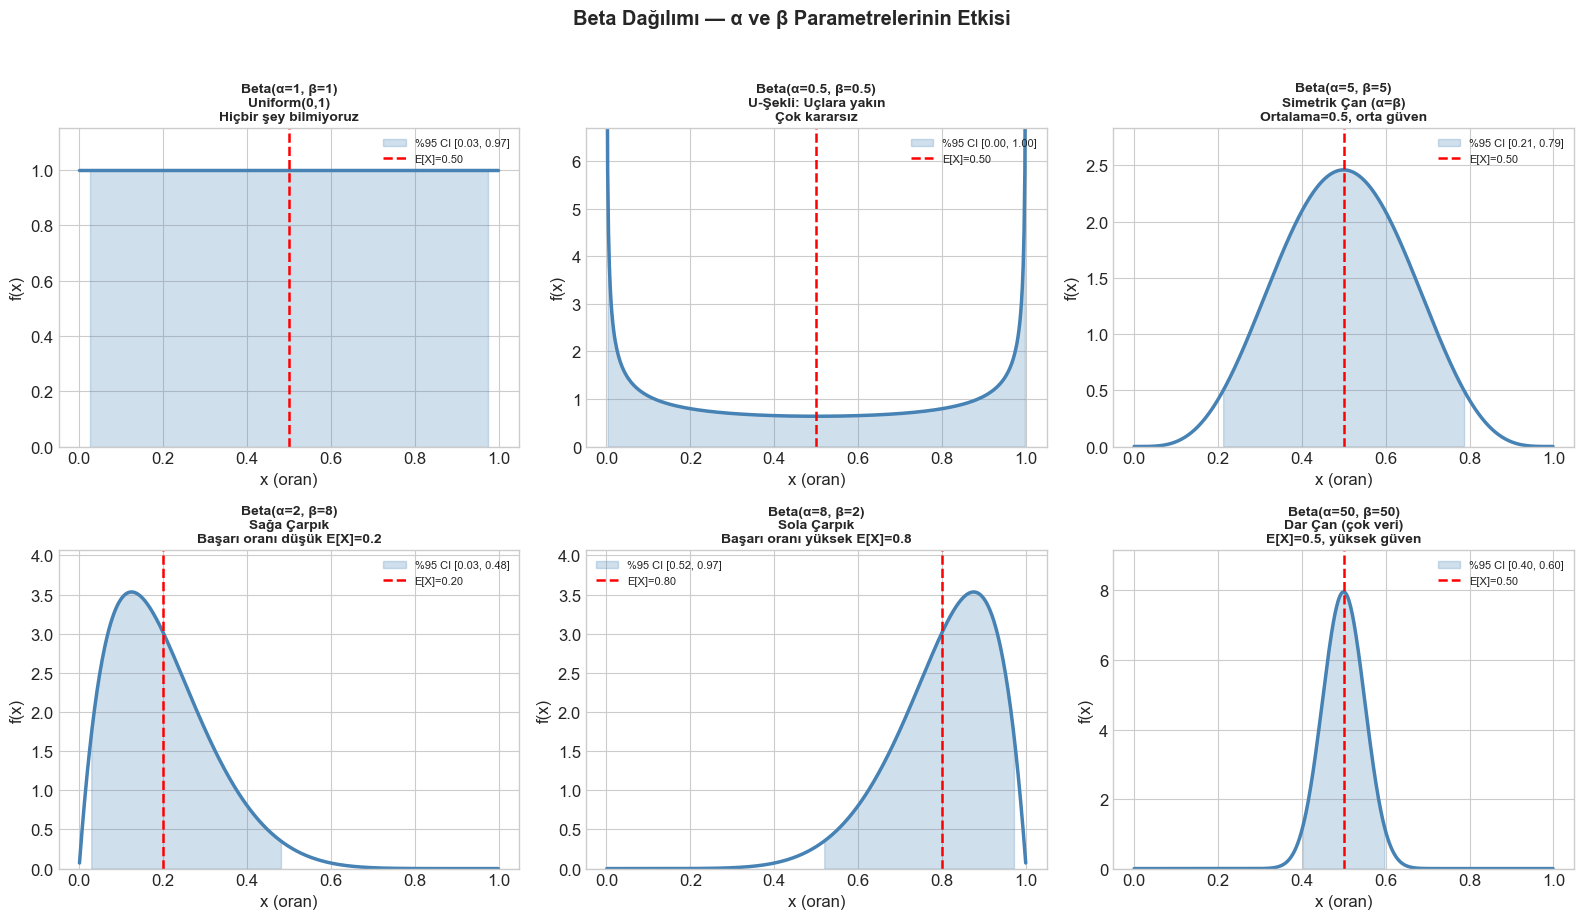

=== Beta Parametreleri ve Beklenti/Varyans ===
    α     β     E[X]     Var(X)      Std 95% CI
    1     1   0.5000   0.083333   0.2887  [0.025, 0.975]
  0.5   0.5   0.5000   0.125000   0.3536  [0.002, 0.998]
    5     5   0.5000   0.022727   0.1508  [0.212, 0.788]
    2     8   0.2000   0.014545   0.1206  [0.028, 0.482]
    8     2   0.8000   0.014545   0.1206  [0.518, 0.972]
   50    50   0.5000   0.002475   0.0498  [0.403, 0.597]


In [23]:
x = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

parametreler = [
    (1,   1,   'Uniform(0,1)\nHiçbir şey bilmiyoruz'),
    (0.5, 0.5, 'U-Şekli: Uçlara yakın\nÇok kararsız'),
    (5,   5,   'Simetrik Çan (α=β)\nOrtalama=0.5, orta güven'),
    (2,   8,   'Sağa Çarpık\nBaşarı oranı düşük E[X]=0.2'),
    (8,   2,   'Sola Çarpık\nBaşarı oranı yüksek E[X]=0.8'),
    (50, 50,   'Dar Çan (çok veri)\nE[X]=0.5, yüksek güven'),
]

for ax, (a, b, baslik) in zip(axes.flat, parametreler):
    dist = stats.beta(a=a, b=b)
    y    = dist.pdf(x)
    mu   = dist.mean()
    ci_l = dist.ppf(0.025)   # %95 CI alt
    ci_u = dist.ppf(0.975)   # %95 CI ust

    ax.plot(x, y, 'steelblue', linewidth=2.5)
    ax.fill_between(x, y,
                    where=((x >= ci_l) & (x <= ci_u)),
                    alpha=0.25, color='steelblue',
                    label=f'%95 CI [{ci_l:.2f}, {ci_u:.2f}]')
    ax.axvline(mu, color='red', linewidth=1.8, linestyle='--',
               label=f'E[X]={mu:.2f}')

    # y eksenini sınırla (U-şekli için çok yükseldiğinden)
    y_max = min(np.nanmax(y[1:-1]), 8)
    ax.set_ylim(0, y_max * 1.15)

    ax.set_xlabel('x (oran)')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Beta(α={a}, β={b})\n{baslik}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Beta Dağılımı — α ve β Parametrelerinin Etkisi', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== Beta Parametreleri ve Beklenti/Varyans ===')
print(f'{"α":>5} {"β":>5} {"E[X]":>8} {"Var(X)":>10} {"Std":>8} {"95% CI"}')
for a, b, _ in parametreler:
    dist = stats.beta(a, b)
    mu   = a / (a + b)
    var  = (a*b) / ((a+b)**2 * (a+b+1))
    print(f'{a:>5} {b:>5} {mu:>8.4f} {var:>10.6f} {var**0.5:>8.4f}'
          f'  [{dist.ppf(0.025):.3f}, {dist.ppf(0.975):.3f}]')


---
### 💰 Python 2 — Bayesian A/B: Adult Income CTR Prior → Posterior

**Veri:** `adult-income.csv` — 32.561 kişi, `income` = `<=50K` veya `>50K`

**Senaryo:**  
"Bir kişinin yüksek gelirli (>50K) olma olasılığı nedir?"  
Bu soruyu Bayesian yaklaşımla cevaplıyoruz — her meslekte ayrı ayrı.

**Mantık:**  
- **Prior:** Beta(1,1) — hiçbir şey bilmiyoruz, Uniform
- **Likelihood:** n deneme, k başarı (>50K)
- **Posterior:** Beta(1+k, 1+n-k) — veriyi gördükten sonraki inanç
- Her yeni veriyle prior'ı güncelle → posterior'ı görselleştir

Bu, A/B test conversion rate tahmini için de aynı mantık.

Yuklendi: 32,561 satir
Sutunlar: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Genel >50K oranı: 0.2408 = %24.08
n=32,561, k=7,841


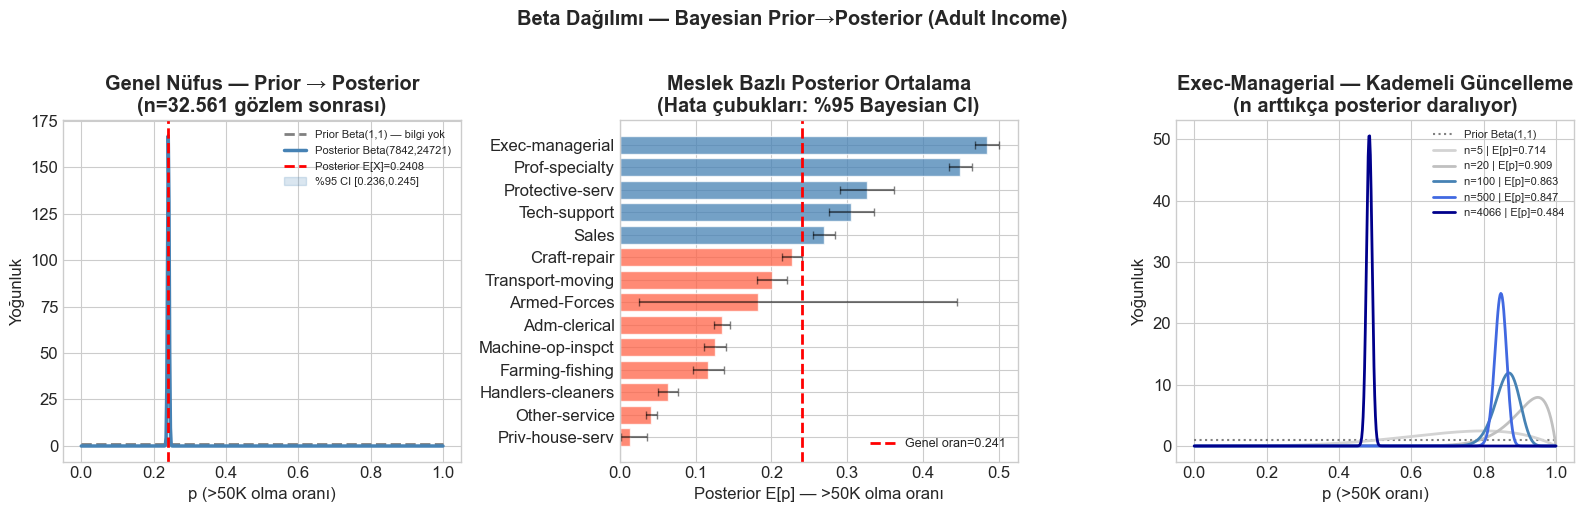

=== Meslek Bazlı Posterior Özeti ===
Meslek                              n      k     E[p] 95% CI
Exec-managerial                  4066   1968   0.4840  [0.469, 0.499]
Prof-specialty                   4140   1859   0.4491  [0.434, 0.464]
Protective-serv                   649    211   0.3257  [0.290, 0.362]
Tech-support                      928    283   0.3054  [0.276, 0.335]
Sales                            3650    983   0.2694  [0.255, 0.284]
Craft-repair                     4099    929   0.2268  [0.214, 0.240]
Transport-moving                 1597    320   0.2008  [0.181, 0.221]
Armed-Forces                        9      1   0.1818  [0.025, 0.445]
Adm-clerical                     3770    507   0.1347  [0.124, 0.146]
Machine-op-inspct                2002    250   0.1252  [0.111, 0.140]
Farming-fishing                   994    115   0.1165  [0.097, 0.137]
Handlers-cleaners                1370     86   0.0634  [0.051, 0.077]
Other-service                    3295    137   0.0419  [0.035,

In [24]:
adult = pd.read_csv(f'{DATA_PATH}/adult-income.csv')

print(f'Yuklendi: {len(adult):,} satir')
print('Sutunlar:', adult.columns.tolist())
print(adult['income'].value_counts())

# Yüksek gelir bayragi
adult['yuksek_gelir'] = (adult['income'].str.strip() == '>50K').astype(int)

genel_oran = adult['yuksek_gelir'].mean()
n_top, k_top = len(adult), adult['yuksek_gelir'].sum()
print(f'\nGenel >50K oranı: {genel_oran:.4f} = %{genel_oran*100:.2f}')
print(f'n={n_top:,}, k={k_top:,}')

# ─── Bayesian guncelleme ─────────────────────────────────────────────────────
x = np.linspace(0, 1, 500)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sol: prior → posterior genel nufus
ax = axes[0]
prior = stats.beta(1, 1)                       # Beta(1,1) = Uniform
posterior = stats.beta(1 + k_top, 1 + n_top - k_top)

ax.plot(x, prior.pdf(x), 'gray', linewidth=2, linestyle='--', label='Prior Beta(1,1) — bilgi yok')
ax.plot(x, posterior.pdf(x), 'steelblue', linewidth=2.5,
        label=f'Posterior Beta({1+k_top},{1+n_top-k_top})')
ax.axvline(posterior.mean(), color='red', linewidth=2, linestyle='--',
           label=f'Posterior E[X]={posterior.mean():.4f}')
ci_l, ci_u = posterior.ppf(0.025), posterior.ppf(0.975)
ax.fill_between(x, posterior.pdf(x),
                where=((x >= ci_l) & (x <= ci_u)),
                alpha=0.2, color='steelblue',
                label=f'%95 CI [{ci_l:.3f},{ci_u:.3f}]')
ax.set_xlabel('p (>50K olma oranı)')
ax.set_ylabel('Yoğunluk')
ax.set_title('Genel Nüfus — Prior → Posterior\n(n=32.561 gözlem sonrası)', fontweight='bold')
ax.legend(fontsize=8)

# Orta: Meslek bazlı posterior ortalamalari
ax = axes[1]
meslek_ozet = adult.groupby('occupation')['yuksek_gelir'].agg(['sum','count']).reset_index()
meslek_ozet.columns = ['meslek','k','n']
# Posterior: Beta(1+k, 1+n-k) — her meslek icin
meslek_ozet['post_mean'] = (1 + meslek_ozet['k']) / (2 + meslek_ozet['n'])
meslek_ozet['post_ci_l'] = meslek_ozet.apply(
    lambda r: stats.beta(1+r['k'], 1+r['n']-r['k']).ppf(0.025), axis=1)
meslek_ozet['post_ci_u'] = meslek_ozet.apply(
    lambda r: stats.beta(1+r['k'], 1+r['n']-r['k']).ppf(0.975), axis=1)
meslek_ozet = meslek_ozet[meslek_ozet['meslek'] != '?'].sort_values('post_mean')

renkler_bar = ['tomato' if m < genel_oran else 'steelblue'
               for m in meslek_ozet['post_mean']]
bars = ax.barh(meslek_ozet['meslek'], meslek_ozet['post_mean'],
               color=renkler_bar, alpha=0.75, edgecolor='white')
ax.errorbar(meslek_ozet['post_mean'], meslek_ozet['meslek'],
            xerr=[meslek_ozet['post_mean']-meslek_ozet['post_ci_l'],
                  meslek_ozet['post_ci_u']-meslek_ozet['post_mean']],
            fmt='none', color='black', capsize=3, alpha=0.5)
ax.axvline(genel_oran, color='red', linestyle='--', linewidth=2,
           label=f'Genel oran={genel_oran:.3f}')
ax.set_xlabel('Posterior E[p] — >50K olma oranı')
ax.set_title('Meslek Bazlı Posterior Ortalama\n(Hata çubukları: %95 Bayesian CI)', fontweight='bold')
ax.legend(fontsize=9)

# Sag: kademeli guncelleme (ilk N gozlemde posterior nasil evriliyor?)
ax = axes[2]
exec_data  = adult[adult['occupation'].str.strip() == 'Exec-managerial']
n_exec, k_exec = len(exec_data), exec_data['yuksek_gelir'].sum()

kisim_sayisi = [5, 20, 100, 500, n_exec]
renkler_gunc = ['lightgray','silver','steelblue','royalblue','darkblue']

ax.plot(x, stats.beta(1,1).pdf(x), 'gray', linewidth=1.5,
        linestyle=':', label='Prior Beta(1,1)')

for kisim, renk in zip(kisim_sayisi, renkler_gunc):
    alt  = exec_data.head(kisim)
    k_a  = alt['yuksek_gelir'].sum()
    n_a  = len(alt)
    post = stats.beta(1+k_a, 1+n_a-k_a)
    ax.plot(x, post.pdf(x), color=renk, linewidth=2,
            label=f'n={kisim} | E[p]={post.mean():.3f}')

ax.set_xlabel('p (>50K oranı)')
ax.set_ylabel('Yoğunluk')
ax.set_title('Exec-Managerial — Kademeli Güncelleme\n(n arttıkça posterior daralıyor)', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Beta Dağılımı — Bayesian Prior→Posterior (Adult Income)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== Meslek Bazlı Posterior Özeti ===')
print(f'{"Meslek":<30} {"n":>6} {"k":>6} {"E[p]":>8} {"95% CI"}')
for _, row in meslek_ozet.sort_values('post_mean', ascending=False).iterrows():
    print(f'{row["meslek"]:<30} {int(row["n"]):>6} {int(row["k"]):>6}'
          f' {row["post_mean"]:>8.4f}  [{row["post_ci_l"]:.3f}, {row["post_ci_u"]:.3f}]')


---
### 🛒 Python 3 — Log-Normal Fit: E-Ticaret Fiyatları

**Veri:** `commerce-purchase.csv` — 2.6 milyon satır, `price` sütunu

**Ne yapıyoruz?**
1. Raw fiyat dağılımı — Log-Normal fit
2. `log(price)` dönüşümü — Normal mi?
3. Kategori bazlı Log-Normal fit karşılaştırması

**Mantık:**
- `stats.lognorm.fit(data, floc=0)` → MLE: `(sigma, loc=0, scale=exp(mu))`  
  Dikkat: scipy `lognorm`'da dönen `scale = exp(μ)`, `s = σ`
- `np.log(data)` → log-ölçeğe geç, `stats.norm.fit()` ile μ ve σ tahmin et
- Log-ölçekte Normal → orijinal ölçekte Log-Normal

Yuklendi: 2,201,446 satir (price > 0)
count    2201446.00
mean         154.10
std          241.95
min            0.02
25%           14.56
50%           55.53
75%          196.74
max        50925.90
Name: price, dtype: float64
Carpiklik: 8.389  (saga carpik → Log-Normal adayi)
Ortalama : 154.10  |  Medyan: 55.53
Ort > Medyan cok → saga carpik onaylandi

Log-Normal MLE fit:
  μ (log-ölçekte)     = 3.9230
  σ (log-ölçekte)     = 1.7207
  E[X] = exp(μ+σ²/2) = 222.15  (gercek ort: 154.10)
  Medyan = exp(μ)     = 50.55          (gercek med: 55.53)


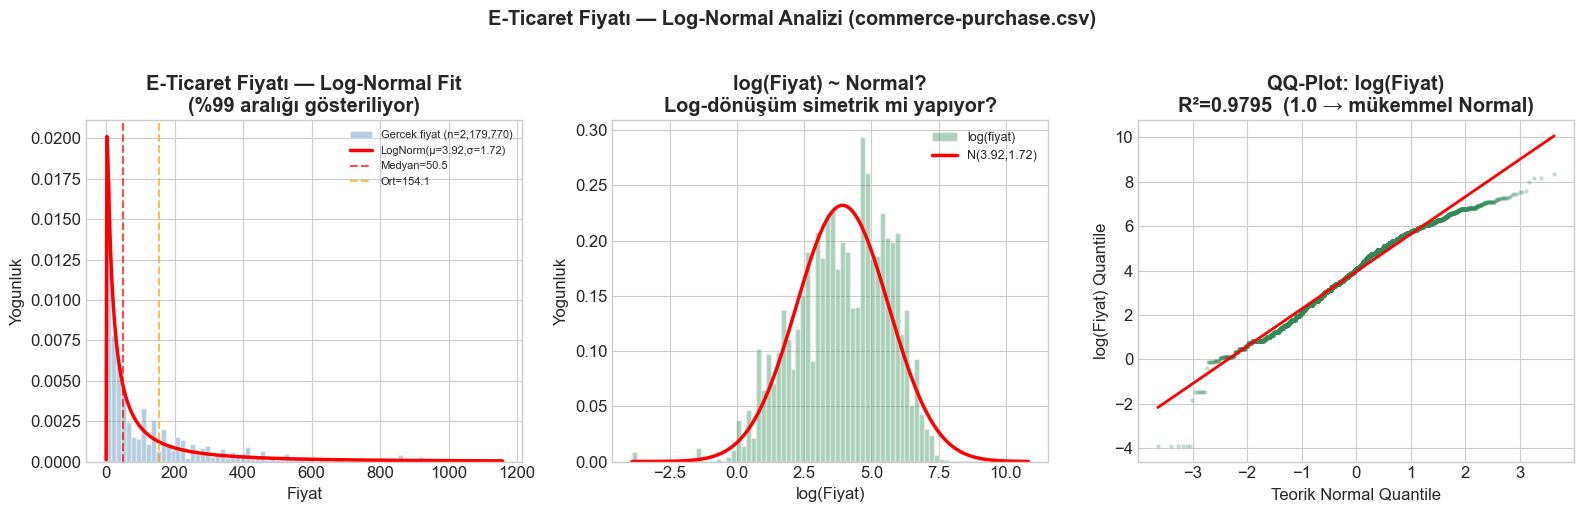

In [25]:
# Buyuk dosya — sadece price sutununu yukle
ecom = pd.read_csv(f'{DATA_PATH}/commerce-purchase.csv',
                   usecols=['price','category_code','brand'])
# Sifir ve negatif fiyatlari cikar (log alamayiz)
ecom = ecom[ecom['price'] > 0].dropna(subset=['price'])

print(f'Yuklendi: {len(ecom):,} satir (price > 0)')
print(ecom['price'].describe().round(2))
print(f'Carpiklik: {stats.skew(ecom["price"]):.3f}  (saga carpik → Log-Normal adayi)')
print(f'Ortalama : {ecom["price"].mean():.2f}  |  Medyan: {ecom["price"].median():.2f}')
print(f'Ort > Medyan cok → saga carpik onaylandi')

fiyat = ecom['price'].values

# ─── Log-Normal MLE ──────────────────────────────────────────────────────────
# floc=0: fiyat negatif olamaz
# Donus: (sigma, loc=0, scale=exp(mu))
sigma_ln, loc_ln, scale_ln = stats.lognorm.fit(fiyat, floc=0)
mu_ln = np.log(scale_ln)   # scale = exp(mu) → mu = log(scale)

print(f'\nLog-Normal MLE fit:')
print(f'  μ (log-ölçekte)     = {mu_ln:.4f}')
print(f'  σ (log-ölçekte)     = {sigma_ln:.4f}')
print(f'  E[X] = exp(μ+σ²/2) = {np.exp(mu_ln + sigma_ln**2/2):.2f}  (gercek ort: {fiyat.mean():.2f})')
print(f'  Medyan = exp(μ)     = {np.exp(mu_ln):.2f}          (gercek med: {np.median(fiyat):.2f})')

# ─── Grafik ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sol: Raw fiyat histogrami vs Log-Normal fit
ax = axes[0]
q99 = np.quantile(fiyat, 0.99)
fiyat_clip = fiyat[fiyat <= q99]
ax.hist(fiyat_clip, bins=80, density=True,
        color='steelblue', alpha=0.4, edgecolor='white',
        label=f'Gercek fiyat (n={len(fiyat_clip):,})')
x_r = np.linspace(0.01, q99, 500)
lndist = stats.lognorm(s=sigma_ln, scale=scale_ln)
ax.plot(x_r, lndist.pdf(x_r), 'r-', linewidth=2.5,
        label=f'LogNorm(μ={mu_ln:.2f},σ={sigma_ln:.2f})')
ax.axvline(np.exp(mu_ln), color='red', linestyle='--', alpha=0.7,
           label=f'Medyan={np.exp(mu_ln):.1f}')
ax.axvline(fiyat.mean(), color='orange', linestyle='--', alpha=0.7,
           label=f'Ort={fiyat.mean():.1f}')
ax.set_xlabel('Fiyat')
ax.set_ylabel('Yogunluk')
ax.set_title('E-Ticaret Fiyatı — Log-Normal Fit\n(%99 aralığı gösteriliyor)', fontweight='bold')
ax.legend(fontsize=8)

# Orta: log(fiyat) → Normal mi?
ax = axes[1]
log_fiyat = np.log(fiyat)
mu_lf, sigma_lf = stats.norm.fit(log_fiyat)
ax.hist(log_fiyat, bins=80, density=True,
        color='seagreen', alpha=0.4, edgecolor='white',
        label='log(fiyat)')
x_lf = np.linspace(log_fiyat.min(), log_fiyat.max(), 400)
ax.plot(x_lf, stats.norm.pdf(x_lf, mu_lf, sigma_lf),
        'r-', linewidth=2.5,
        label=f'N({mu_lf:.2f},{sigma_lf:.2f})')
ax.set_xlabel('log(Fiyat)')
ax.set_ylabel('Yogunluk')
ax.set_title('log(Fiyat) ~ Normal?\nLog-dönüşüm simetrik mi yapıyor?', fontweight='bold')
ax.legend(fontsize=9)

# Sag: QQ-Plot log(fiyat)
ax = axes[2]
orneklem = np.random.choice(log_fiyat, size=5000, replace=False)
(tq, gq), (slope, intercept, r) = stats.probplot(orneklem, dist='norm')
ax.scatter(tq, gq, alpha=0.2, s=5, color='seagreen')
x_line = np.array([tq.min(), tq.max()])
ax.plot(x_line, slope*x_line + intercept, 'r-', linewidth=2)
ax.set_xlabel('Teorik Normal Quantile')
ax.set_ylabel('log(Fiyat) Quantile')
ax.set_title(f'QQ-Plot: log(Fiyat)\nR²={r**2:.4f}  (1.0 → mükemmel Normal)', fontweight='bold')

plt.suptitle('E-Ticaret Fiyatı — Log-Normal Analizi (commerce-purchase.csv)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
### 🔬 Python 4 — Normal vs Log-Normal: Hangisi Daha İyi Fit?

**Ne yapıyoruz?**  
Adult Income'daki `hours.per.week` (haftalık çalışma saati) verisini hem Normal hem Log-Normal ile fit ediyoruz.

**Neden bu sütun?** Çalışma saati sağa çarpık olabilir — Normal mi, Log-Normal mi daha iyi?  
Bu karşılaştırma, gerçek hayatta "hangi dağılımı seçeyim?" sorusunun pratik cevabıdır.

**Karar kriteri:**
- QQ-Plot: hangi fit daha düz doğru veriyor?
- AIC: daha küçük olan daha iyi
- `stats.kstest`: p-değeri daha büyük olan daha iyi

Haftalik calisma saati: n=32,561
Ort=40.44, Medyan=40.00, Std=12.35
Carpiklik=0.228

Normal   : μ=40.44, σ=12.35  | AIC=256087.9
Log-Normal: μ=3.6360, σ=0.4101 | AIC=271144.7
Kazanan  : Normal (dusuk AIC)


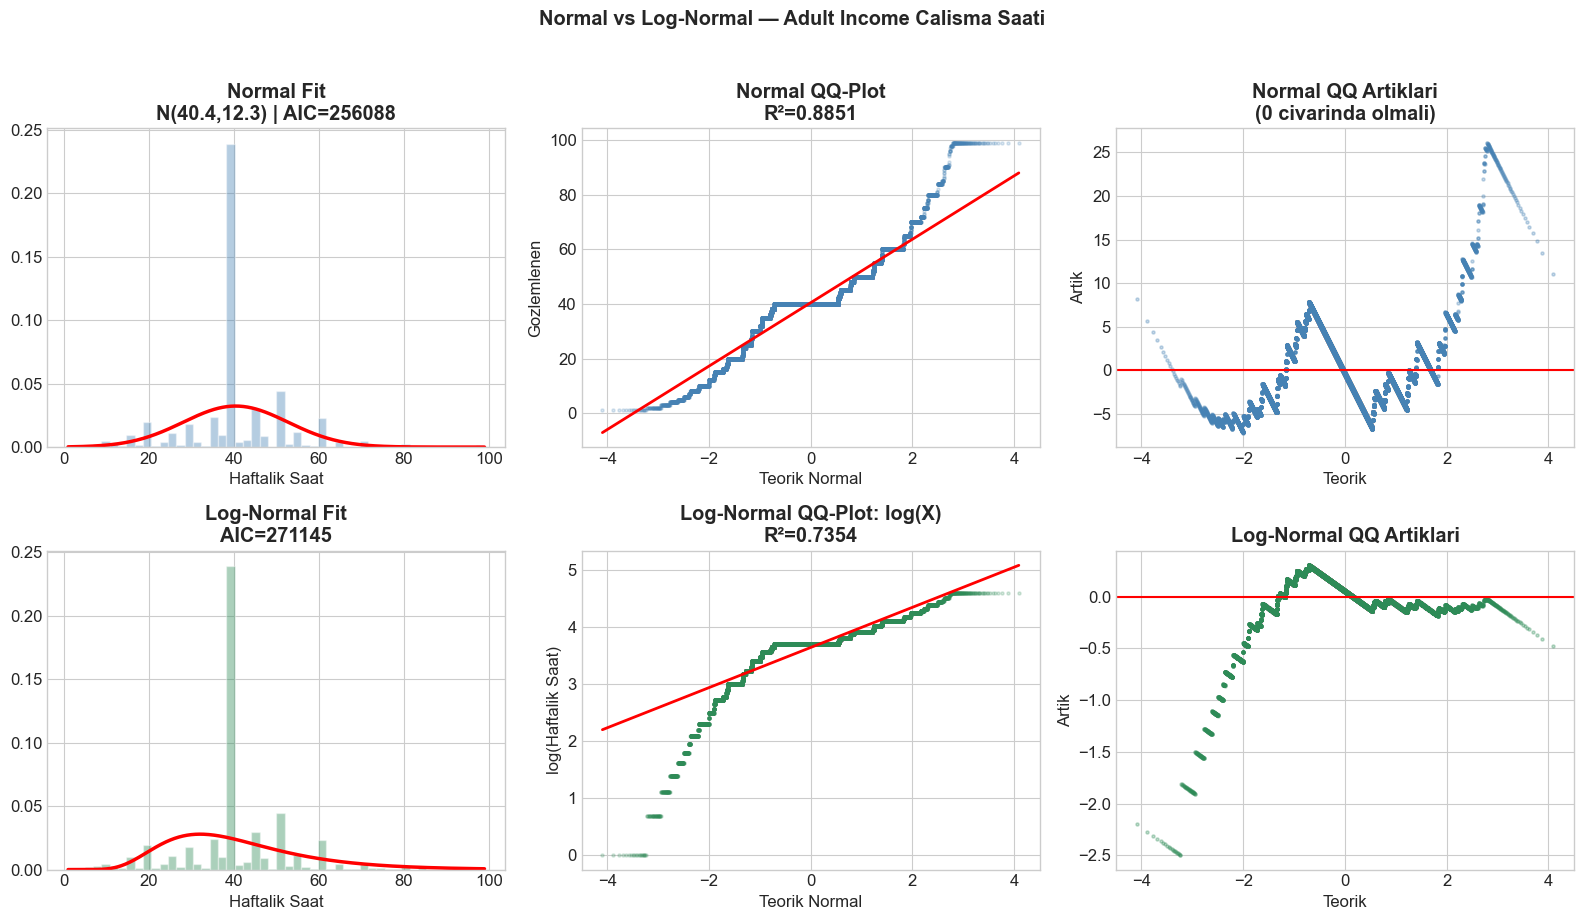


Karsilastirma: Normal R²=0.8851 vs Log-Normal R²=0.7354
Kazanan (yuksek R²): Normal


In [26]:
# Calisma saati verisi (yalnizca pozitif)
saat = adult['hours.per.week'].values
saat = saat[saat > 0]

print(f'Haftalik calisma saati: n={len(saat):,}')
print(f'Ort={saat.mean():.2f}, Medyan={np.median(saat):.2f}, Std={saat.std():.2f}')
print(f'Carpiklik={stats.skew(saat):.3f}')

# MLE: Normal
mu_n, sigma_n = stats.norm.fit(saat)
ll_n = stats.norm(mu_n, sigma_n).logpdf(saat).sum()
aic_n = 2*2 - 2*ll_n

# MLE: Log-Normal
s_ln, loc_ln2, scale_ln2 = stats.lognorm.fit(saat, floc=0)
ll_ln = stats.lognorm(s_ln, loc_ln2, scale_ln2).logpdf(saat).sum()
aic_ln = 2*2 - 2*ll_ln

print(f'\nNormal   : μ={mu_n:.2f}, σ={sigma_n:.2f}  | AIC={aic_n:.1f}')
print(f'Log-Normal: μ={np.log(scale_ln2):.4f}, σ={s_ln:.4f} | AIC={aic_ln:.1f}')
print(f'Kazanan  : {"Log-Normal" if aic_ln < aic_n else "Normal"} (dusuk AIC)')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Ust sira: Normal fit
# Histogram + fit
ax = axes[0][0]
ax.hist(saat, bins=50, density=True, color='steelblue', alpha=0.4, edgecolor='white')
x_r = np.linspace(saat.min(), saat.max(), 400)
ax.plot(x_r, stats.norm.pdf(x_r, mu_n, sigma_n), 'r-', linewidth=2.5)
ax.set_title(f'Normal Fit\nN({mu_n:.1f},{sigma_n:.1f}) | AIC={aic_n:.0f}', fontweight='bold')
ax.set_xlabel('Haftalik Saat')

# QQ-Plot: Normal
ax = axes[0][1]
(tq, gq), (slope, intercept, r_n) = stats.probplot(saat, dist='norm')
ax.scatter(tq, gq, alpha=0.2, s=5, color='steelblue')
ax.plot([tq.min(), tq.max()],
        [slope*tq.min()+intercept, slope*tq.max()+intercept], 'r-', linewidth=2)
ax.set_title(f'Normal QQ-Plot\nR²={r_n**2:.4f}', fontweight='bold')
ax.set_xlabel('Teorik Normal')
ax.set_ylabel('Gozlemlenen')

# Residuals: Normal
ax = axes[0][2]
resid_n = gq - (slope*tq + intercept)
ax.scatter(tq, resid_n, alpha=0.3, s=5, color='steelblue')
ax.axhline(0, color='red', linewidth=1.5)
ax.set_title('Normal QQ Artiklari\n(0 civarinda olmali)', fontweight='bold')
ax.set_xlabel('Teorik')
ax.set_ylabel('Artik')

# Alt sira: Log-Normal fit
ax = axes[1][0]
ax.hist(saat, bins=50, density=True, color='seagreen', alpha=0.4, edgecolor='white')
lndist2 = stats.lognorm(s_ln, loc=0, scale=scale_ln2)
ax.plot(x_r, lndist2.pdf(x_r), 'r-', linewidth=2.5)
ax.set_title(f'Log-Normal Fit\nAIC={aic_ln:.0f}', fontweight='bold')
ax.set_xlabel('Haftalik Saat')

# QQ-Plot: Log-Normal = log(X) Normal mi?
ax = axes[1][1]
log_saat = np.log(saat)
(tq2, gq2), (slope2, intercept2, r_ln) = stats.probplot(log_saat, dist='norm')
ax.scatter(tq2, gq2, alpha=0.2, s=5, color='seagreen')
ax.plot([tq2.min(), tq2.max()],
        [slope2*tq2.min()+intercept2, slope2*tq2.max()+intercept2], 'r-', linewidth=2)
ax.set_title(f'Log-Normal QQ-Plot: log(X)\nR²={r_ln**2:.4f}', fontweight='bold')
ax.set_xlabel('Teorik Normal')
ax.set_ylabel('log(Haftalik Saat)')

ax = axes[1][2]
resid_ln = gq2 - (slope2*tq2 + intercept2)
ax.scatter(tq2, resid_ln, alpha=0.3, s=5, color='seagreen')
ax.axhline(0, color='red', linewidth=1.5)
ax.set_title('Log-Normal QQ Artiklari', fontweight='bold')
ax.set_xlabel('Teorik')
ax.set_ylabel('Artik')

plt.suptitle('Normal vs Log-Normal — Adult Income Calisma Saati', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nKarsilastirma: Normal R²={r_n**2:.4f} vs Log-Normal R²={r_ln**2:.4f}')
print(f'Kazanan (yuksek R²): {"Normal" if r_n**2 > r_ln**2 else "Log-Normal"}')


---
### 🛒 Python 5 — Kategori Bazlı Log-Normal: Commerce Fiyat Analizi

**Ne yapıyoruz?**  
E-ticaret verisinde en çok satılan kategorileri bulup her birinin fiyat dağılımını ayrı Log-Normal ile fit ediyoruz.

**Neden kategori bazlı?**  
Tüm ürünlerin tek bir dağılıma uyması beklenmez — elektronik vs gıda çok farklı fiyat profilleri.
Bu, Poisson notebook'taki saat bazlı λ analojisidir.

Top 6 kategori: ['appliances', 'electronics', 'computers', 'furniture', 'stationery', 'accessories']


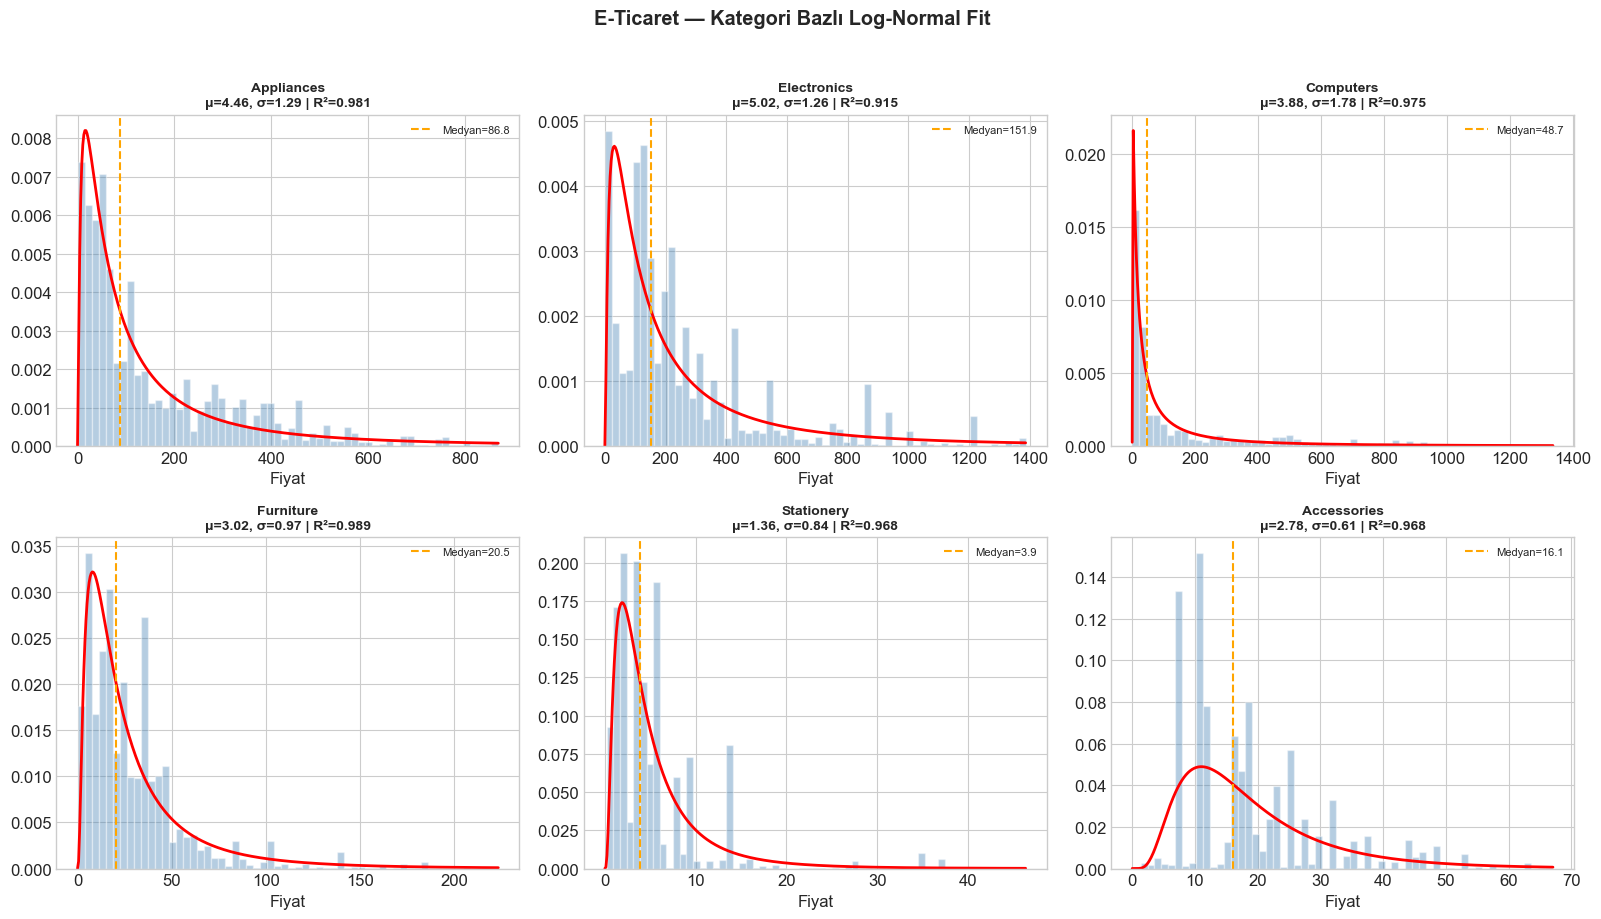


=== Kategori Bazlı Log-Normal Özet Tablosu ===
   Kategori      n  μ (log)  σ (log)  Medyan ($)  E[X] ($)  QQ R²
 appliances 608905    4.464    1.294       86.82    200.68 0.9806
electronics 549038    5.023    1.260      151.86    335.93 0.9149
  computers 222632    3.885    1.780       48.66    237.16 0.9754
  furniture 121364    3.019    0.968       20.47     32.71 0.9887
 stationery  39550    1.358    0.841        3.89      5.54 0.9682
accessories  13620    2.776    0.613       16.06     19.38 0.9677

Not: QQ R² > 0.99 → Log-Normal mükemmel fit


In [27]:
# category_code'dan ana kategori al (ilk kisim: 'electronics.audio' → 'electronics')
ecom['ana_kategori'] = ecom['category_code'].str.split('.').str[0]
ecom = ecom.dropna(subset=['ana_kategori'])

# En cok islem yapilan 6 kategori
top_kat = ecom['ana_kategori'].value_counts().head(6).index.tolist()

print('Top 6 kategori:', top_kat)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ozet_tablo = []

for ax, kat in zip(axes.flat, top_kat):
    alt   = ecom[ecom['ana_kategori'] == kat]['price'].values
    alt   = alt[alt > 0]
    if len(alt) < 100:
        ax.axis('off')
        continue

    # Log-Normal MLE
    s_k, _, sc_k = stats.lognorm.fit(alt, floc=0)
    mu_k   = np.log(sc_k)
    dist_k = stats.lognorm(s=s_k, scale=sc_k)

    # Log-olcekte Normal mi?
    log_alt = np.log(alt)
    (_, _), (_, _, r_k) = stats.probplot(np.random.choice(log_alt, min(2000,len(log_alt))), dist='norm')

    ozet_tablo.append({
        'Kategori'   : kat,
        'n'          : len(alt),
        'μ (log)'    : round(mu_k, 3),
        'σ (log)'    : round(s_k, 3),
        'Medyan ($)' : round(np.exp(mu_k), 2),
        'E[X] ($)'   : round(np.exp(mu_k + s_k**2/2), 2),
        'QQ R²'      : round(r_k**2, 4)
    })

    q99 = np.quantile(alt, 0.99)
    ax.hist(alt[alt <= q99], bins=60, density=True,
            color='steelblue', alpha=0.4, edgecolor='white')
    x_r = np.linspace(0.01, q99, 400)
    ax.plot(x_r, dist_k.pdf(x_r), 'r-', linewidth=2)
    ax.axvline(np.exp(mu_k), color='orange', linewidth=1.5, linestyle='--',
               label=f'Medyan={np.exp(mu_k):.1f}')
    ax.set_title(
        f'{kat.capitalize()}\n'
        f'μ={mu_k:.2f}, σ={s_k:.2f} | R²={r_k**2:.3f}',
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('Fiyat')
    ax.legend(fontsize=8)

plt.suptitle('E-Ticaret — Kategori Bazlı Log-Normal Fit', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Kategori Bazlı Log-Normal Özet Tablosu ===')
ozet_df = pd.DataFrame(ozet_tablo)
print(ozet_df.to_string(index=False))
print('\nNot: QQ R² > 0.99 → Log-Normal mükemmel fit')


---
# 📊 R Uygulaması

| Prefix | Beta | Log-Normal |
|---|---|---|
| `d` (PDF) | `dbeta(x, shape1, shape2)` | `dlnorm(x, meanlog, sdlog)` |
| `p` (CDF) | `pbeta(q, shape1, shape2)` | `plnorm(q, meanlog, sdlog)` |
| `q` (Quantile) | `qbeta(p, shape1, shape2)` | `qlnorm(p, meanlog, sdlog)` |
| `r` (Örnekleme) | `rbeta(n, shape1, shape2)` | `rlnorm(n, meanlog, sdlog)` |

**R'da Beta parametreleri:** `shape1 = α`, `shape2 = β`  
**R'da Log-Normal parametreleri:** `meanlog = μ` (log-ölçekte), `sdlog = σ`

In [28]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


---
### 🎨 R 1 — Beta: Şekil Galerisi + Bayesian Güncelleme

**Yeni R kavramı:** `curve(dbeta(x, a, b), from=0, to=1)`  
Python'da `ax.plot(x, stats.beta(a,b).pdf(x))` karşılığı —  
R'da `curve()` fonksiyon grafiği çizmek için en temiz yol.

n= 5   E[p]= 0.4286 
n= 20   E[p]= 0.6364 
n= 100   E[p]= 0.6765 
n= 928   E[p]= 0.3054 

=== Beta Olasilik Sorulari ===
P(p > 0.30) = 0 
P(p < 0.25) = 0.9999 
%95 CI      = 0.2362 - 0.2455 


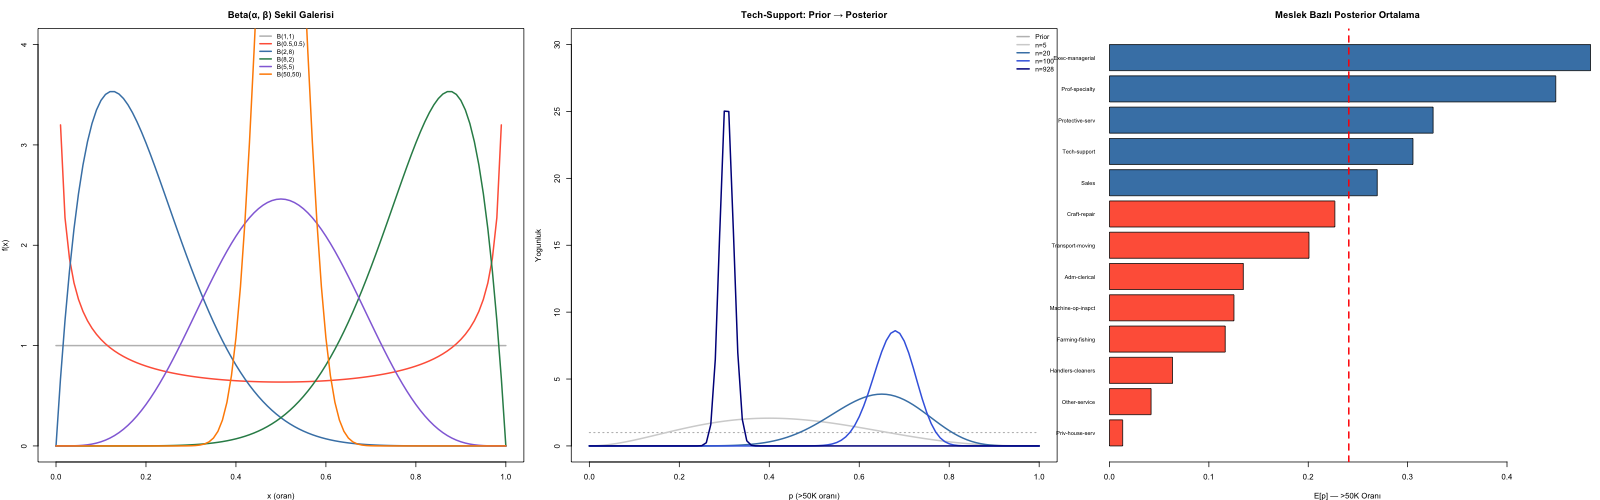

In [29]:
%%R -i adult -w 1600 -h 500

par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))

# ─── Sol: Beta sekil galerisi ─────────────────────────────────────────────────
# curve(): x cinsinden ifade edilen fonksiyonu from-to araliginda cizer
# Python'daki ax.plot(x, stats.beta(a,b).pdf(x)) karsiligi
curve(dbeta(x, 1, 1), from=0, to=1, col='gray', lwd=2, ylim=c(0, 4),
      main='Beta(α, β) Sekil Galerisi', xlab='x (oran)', ylab='f(x)')

params <- list(
    list(a=0.5, b=0.5, col='tomato'),
    list(a=2,   b=8,   col='steelblue'),
    list(a=8,   b=2,   col='seagreen'),
    list(a=5,   b=5,   col='mediumpurple'),
    list(a=50,  b=50,  col='darkorange')
)
for (p in params) {
    curve(dbeta(x, p$a, p$b), add=TRUE, col=p$col, lwd=2)
}
legend('top', bty='n',
       legend=c('B(1,1)','B(0.5,0.5)','B(2,8)','B(8,2)','B(5,5)','B(50,50)'),
       col=c('gray','tomato','steelblue','seagreen','mediumpurple','darkorange'),
       lwd=2, cex=0.8)

# ─── Orta: Bayesian guncelleme ────────────────────────────────────────────────
adult$yuksek <- ifelse(trimws(adult$income) == '>50K', 1, 0)

n_top  <- nrow(adult)
k_top  <- sum(adult$yuksek)
genel  <- k_top / n_top

# Sadece Tech-support meslegini goster
tech    <- adult[trimws(adult$occupation) == 'Tech-support', ]
n_tech  <- nrow(tech)
k_tech  <- sum(tech$yuksek)

kisimlar <- c(5, 20, 100, n_tech)
renkler  <- c('lightgray','steelblue','royalblue','darkblue')

# Prior: Beta(1,1)
curve(dbeta(x, 1, 1), from=0, to=1, col='gray', lwd=1.5, lty=3,
      ylim=c(0, 30), main='Tech-Support: Prior → Posterior',
      xlab='p (>50K oranı)', ylab='Yogunluk')

for (i in seq_along(kisimlar)) {
    alt  <- head(tech, kisimlar[i])
    k_a  <- sum(alt$yuksek)
    n_a  <- nrow(alt)
    a_p  <- 1 + k_a
    b_p  <- 1 + n_a - k_a
    e_p  <- a_p / (a_p + b_p)
    curve(dbeta(x, a_p, b_p), add=TRUE, col=renkler[i], lwd=2)
    cat('n=', kisimlar[i], '  E[p]=', round(e_p, 4), '\n')
}
legend('topright', bty='n',
       legend=c('Prior', paste0('n=',kisimlar)),
       col=c('gray', renkler), lwd=2, cex=0.85)

# ─── Sag: Meslek bazli posterior ortalamalari ─────────────────────────────────
# Her meslek icin: E[posterior] = (1+k) / (2+n)
meslekler <- tapply(adult$yuksek, trimws(adult$occupation), function(x) {
    k <- sum(x); n <- length(x)
    c(post_mean = (1+k)/(2+n), n=n)
})

ozet <- do.call(rbind, lapply(names(meslekler), function(m) {
    v <- meslekler[[m]]
    data.frame(meslek=m, post_mean=v['post_mean'], n=v['n'])
}))
ozet <- ozet[ozet$n > 50 & trimws(ozet$meslek) != '?', ]
ozet <- ozet[order(ozet$post_mean), ]

barplot(ozet$post_mean,
        names.arg=ozet$meslek,
        horiz=TRUE, las=1, cex.names=0.7,
        col=ifelse(ozet$post_mean > genel, 'steelblue', 'tomato'),
        main='Meslek Bazlı Posterior Ortalama',
        xlab='E[p] — >50K Oranı')
abline(v=genel, col='red', lty=2, lwd=2)

par(mfrow = c(1, 1))

cat('\n=== Beta Olasilik Sorulari ===\n')
# Genel posterior
a_gen <- 1 + k_top; b_gen <- 1 + n_top - k_top
cat('P(p > 0.30) =', round(1 - pbeta(0.30, a_gen, b_gen), 4), '\n')
cat('P(p < 0.25) =', round(pbeta(0.25, a_gen, b_gen), 4), '\n')
cat('%95 CI      =', round(qbeta(0.025, a_gen, b_gen), 4),
    '-', round(qbeta(0.975, a_gen, b_gen), 4), '\n')


---
### 🛒 R 2 — Log-Normal: Commerce Fiyat Analizi

**Yeni R kavramı:** `MASS::fitdistr(data, 'lognormal')`  
Döndürür: `meanlog` (μ) ve `sdlog` (σ) — log-ölçekte parametreler.  
Python'daki `stats.lognorm.fit(data, floc=0)` karşılığı.

=== Log-Normal MLE ===
     meanlog         sdlog    
  4.3588322097   1.5372912272 
 (0.0012194078) (0.0008622515)
E[X] = exp(μ+σ²/2) = 254.8 
Medyan = exp(μ)     = 78.17 

=== Log-Normal Olasilik Sorulari ===
P(fiyat < 100)       = 0.5637 
P(fiyat > 500)       = 0.1137 
%90 yuzdelik fiyat   = 560.57 


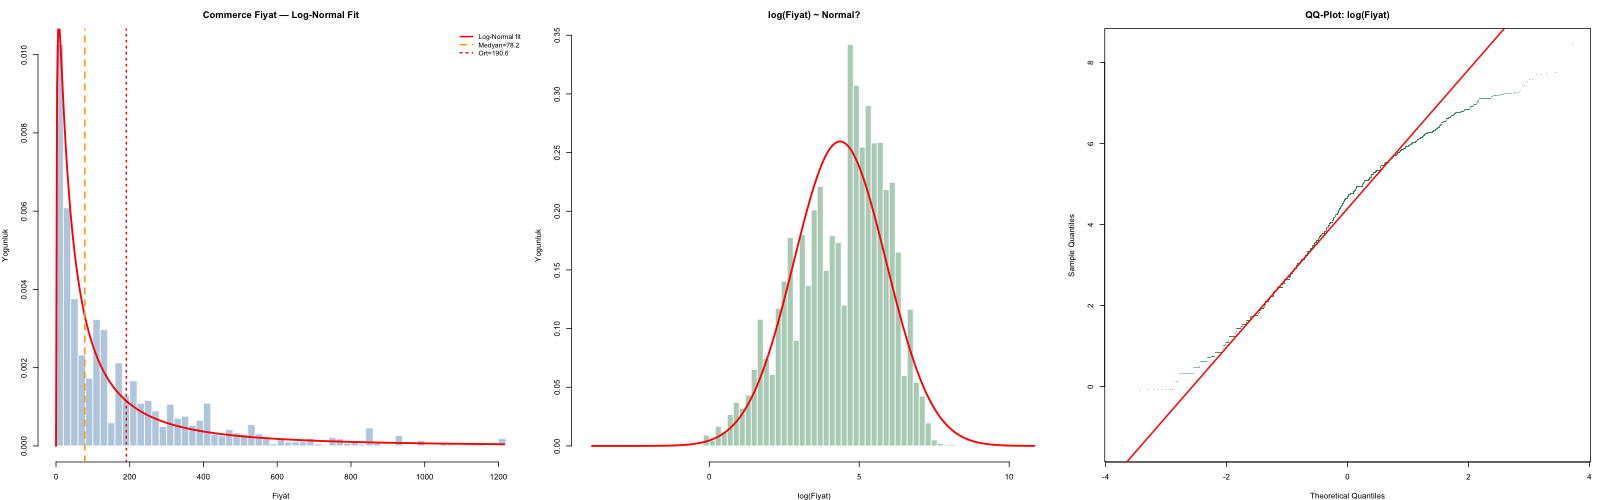

In [31]:
%%R -i ecom -w 1600 -h 500
library(MASS)

fiyat <- ecom$price[ecom$price > 0]
fiyat <- fiyat[!is.na(fiyat)]

# ─── Log-Normal MLE ───────────────────────────────────────────────────────────
# MASS::fitdistr: meanlog (mu) ve sdlog (sigma) tahmin eder
fit_ln <- fitdistr(fiyat, 'lognormal')
cat('=== Log-Normal MLE ===\n')
print(fit_ln)
mu_r  <- fit_ln$estimate['meanlog']
sig_r <- fit_ln$estimate['sdlog']
cat('E[X] = exp(μ+σ²/2) =', round(exp(mu_r + sig_r^2/2), 2), '\n')
cat('Medyan = exp(μ)     =', round(exp(mu_r), 2), '\n')

par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))

# ─── Sol: Histogram + Log-Normal fit ─────────────────────────────────────────
q99 <- quantile(fiyat, 0.99)
fiyat_clip <- fiyat[fiyat <= q99]

hist(fiyat_clip, breaks=80, freq=FALSE,
     col=adjustcolor('steelblue', 0.4), border='white',
     main='Commerce Fiyat — Log-Normal Fit',
     xlab='Fiyat', ylab='Yogunluk')

x_r <- seq(0.01, q99, length.out=400)
lines(x_r, dlnorm(x_r, meanlog=mu_r, sdlog=sig_r),
      col='red', lwd=2.5)
abline(v=exp(mu_r), col='orange', lty=2, lwd=2)  # medyan
abline(v=mean(fiyat), col='red', lty=3, lwd=2)   # ortalama
legend('topright', bty='n',
       legend=c('Log-Normal fit', paste0('Medyan=',round(exp(mu_r),1)),
                paste0('Ort=',round(mean(fiyat),1))),
       col=c('red','orange','red'), lty=c(1,2,3), lwd=2, cex=0.85)

# ─── Orta: log(fiyat) → Normal ───────────────────────────────────────────────
log_fiyat_r <- log(fiyat)
hist(log_fiyat_r, breaks=80, freq=FALSE,
     col=adjustcolor('seagreen', 0.4), border='white',
     main='log(Fiyat) ~ Normal?',
     xlab='log(Fiyat)', ylab='Yogunluk')
x_lf <- seq(min(log_fiyat_r), max(log_fiyat_r), length.out=300)
lines(x_lf, dnorm(x_lf, mu_r, sig_r), col='red', lwd=2.5)

# ─── Sag: QQ-Plot log(fiyat) ─────────────────────────────────────────────────
# qqnorm / qqline: log-olcekte normallik kontrolu
orneklem_r <- sample(log_fiyat_r, 5000)
qqnorm(orneklem_r, pch='.', col=adjustcolor('seagreen', 0.4),
       main='QQ-Plot: log(Fiyat)')
qqline(orneklem_r, col='red', lwd=2)

par(mfrow = c(1, 1))

cat('\n=== Log-Normal Olasilik Sorulari ===\n')
cat('P(fiyat < 100)       =', round(plnorm(100, mu_r, sig_r), 4), '\n')
cat('P(fiyat > 500)       =', round(1 - plnorm(500, mu_r, sig_r), 4), '\n')
cat('%90 yuzdelik fiyat   =', round(qlnorm(0.90, mu_r, sig_r), 2), '\n')


---
# 🗄️ SQL Uygulaması (DuckDB)

SQL'de Beta ve Log-Normal analizi:
1. **Bayesian CTR** → `SUM(yuksek_gelir)`, `COUNT(*)` ile posterior parametreler
2. **Log dönüşümü** → `LN(price)`, `AVG`, `STDDEV` ile Log-Normal MLE
3. **Kategori bazlı** → `GROUP BY` ile her kategori için ayrı fit
4. **Log-Normal olasılık** → Z-score üzerinden tahmin

In [32]:
import duckdb
con = duckdb.connect()
con.register('adult_tbl',  adult)
con.register('ecom_tbl',   ecom)
print('DuckDB hazir ✓')
print(f'adult_tbl: {len(adult):,} satir')
print(f'ecom_tbl : {len(ecom):,} satir')


DuckDB hazir ✓
adult_tbl: 32,561 satir
ecom_tbl : 1,589,331 satir


---
### 💰 SQL 1 — Beta: Bayesian Posterior Parametreler (Adult Income)

SQL'de Beta posterior parametrelerini hesaplamak çok basit:  
- α_posterior = 1 + `SUM(yuksek_gelir)` = 1 + k  
- β_posterior = 1 + `COUNT(*) - SUM(yuksek_gelir)` = 1 + (n-k)  
- E[posterior] = α_posterior / (α_posterior + β_posterior)

In [33]:
# Meslek bazli Bayesian CTR
bayes_sql = con.execute("""
    SELECT
        TRIM(occupation)                            AS meslek,
        COUNT(*)                                    AS n,
        SUM(CASE WHEN TRIM(income)='>50K' THEN 1 ELSE 0 END) AS k,

        -- Beta prior: Beta(1,1) — hicbir bilgi yok
        -- Posterior: Beta(1+k, 1+n-k)
        1 + SUM(CASE WHEN TRIM(income)='>50K' THEN 1 ELSE 0 END) AS alpha_post,
        1 + COUNT(*) - SUM(CASE WHEN TRIM(income)='>50K' THEN 1 ELSE 0 END) AS beta_post,

        -- Posterior beklenti: E[p] = alpha / (alpha + beta)
        ROUND(
            (1.0 + SUM(CASE WHEN TRIM(income)='>50K' THEN 1 ELSE 0 END))
            / (2.0 + COUNT(*)),
        4) AS post_mean,

        -- Ham oran (MLE — kucuk n'de yaniltici)
        ROUND(
            SUM(CASE WHEN TRIM(income)='>50K' THEN 1 ELSE 0 END) * 1.0
            / COUNT(*),
        4) AS mle_oran
    FROM adult_tbl
    WHERE TRIM(occupation) != '?'
    GROUP BY occupation
    HAVING COUNT(*) > 50
    ORDER BY post_mean DESC
""").df()

print('=== Meslek Bazlı Bayesian Posterior (SQL) ===')
print(bayes_sql.to_string(index=False))

# Genel posterior
genel_sql = con.execute("""
    SELECT
        COUNT(*)  AS n,
        SUM(CASE WHEN TRIM(income)='>50K' THEN 1 ELSE 0 END) AS k,
        ROUND((1.0 + SUM(CASE WHEN TRIM(income)='>50K' THEN 1 ELSE 0 END)) / (2.0 + COUNT(*)), 6) AS post_mean
    FROM adult_tbl
""").df()

print('\n=== Genel Posterior ===')
print(genel_sql.to_string(index=False))
print(f'Python sonucu: {adult["yuksek_gelir"].mean():.6f}')
print(f'Neden farkli? SQL Beta(1+k,1+n-k) posterior mean kulaniyor, Python ham oran ama çok uzak değer yok. Python sonucu: {adult["yuksek_gelir"].mean():.6f}, SQL sonucu: {genel_sql["post_mean"].iloc[0]:.6f}')


=== Meslek Bazlı Bayesian Posterior (SQL) ===
           meslek    n      k  alpha_post  beta_post  post_mean  mle_oran
  Exec-managerial 4066 1968.0      1969.0     2099.0     0.4840    0.4840
   Prof-specialty 4140 1859.0      1860.0     2282.0     0.4491    0.4490
  Protective-serv  649  211.0       212.0      439.0     0.3257    0.3251
     Tech-support  928  283.0       284.0      646.0     0.3054    0.3050
            Sales 3650  983.0       984.0     2668.0     0.2694    0.2693
     Craft-repair 4099  929.0       930.0     3171.0     0.2268    0.2266
 Transport-moving 1597  320.0       321.0     1278.0     0.2008    0.2004
     Adm-clerical 3770  507.0       508.0     3264.0     0.1347    0.1345
Machine-op-inspct 2002  250.0       251.0     1753.0     0.1252    0.1249
  Farming-fishing  994  115.0       116.0      880.0     0.1165    0.1157
Handlers-cleaners 1370   86.0        87.0     1285.0     0.0634    0.0628
    Other-service 3295  137.0       138.0     3159.0     0.0419   

---
### 🛒 SQL 2 — Log-Normal MLE: Commerce Fiyat Analizi

Log-Normal MLE formülü SQL'de:
- $\hat{\mu} = \text{AVG}(\ln X)$
- $\hat{\sigma} = \text{STDDEV\_POP}(\ln X)$

Bu, Python'daki `stats.norm.fit(np.log(data))` ile tamamen aynı.

In [34]:
# Genel Log-Normal MLE
ln_genel = con.execute("""
    SELECT
        COUNT(*)                            AS n,
        ROUND(AVG(price), 2)                AS ortalama_fiyat,
        ROUND(MEDIAN(price), 2)             AS medyan_fiyat,

        -- Log-Normal MLE:
        -- mu_hat    = AVG(LN(price))
        -- sigma_hat = STDDEV_POP(LN(price))
        ROUND(AVG(LN(price)), 4)            AS mu_hat,
        ROUND(STDDEV_POP(LN(price)), 4)     AS sigma_hat,

        -- E[X] = exp(mu + sigma^2/2) — teorik ortalama
        ROUND(EXP(AVG(LN(price)) + STDDEV_POP(LN(price))^2 / 2), 2) AS ex_teorik,

        -- Medyan = exp(mu)
        ROUND(EXP(AVG(LN(price))), 2)       AS medyan_teorik
    FROM ecom_tbl
    WHERE price > 0
""").df()

print('=== Log-Normal MLE (SQL) ===')
print(ln_genel.to_string(index=False))

# Kategori bazlı Log-Normal
ln_kat = con.execute("""
    SELECT
        SPLIT_PART(category_code, '.', 1)   AS kategori,
        COUNT(*)                            AS n,
        ROUND(AVG(price), 2)                AS ort_fiyat,
        ROUND(MEDIAN(price), 2)             AS med_fiyat,
        ROUND(AVG(LN(price)), 4)            AS mu,
        ROUND(STDDEV_POP(LN(price)), 4)     AS sigma,
        ROUND(EXP(AVG(LN(price))), 2)       AS medyan_teorik,
        ROUND(EXP(AVG(LN(price)) + STDDEV_POP(LN(price))^2/2), 2) AS ex_teorik
    FROM ecom_tbl
    WHERE price > 0
      AND category_code IS NOT NULL
    GROUP BY SPLIT_PART(category_code, '.', 1)
    HAVING COUNT(*) > 1000
    ORDER BY n DESC
    LIMIT 10
""").df()

print('\n=== Kategori Bazlı Log-Normal MLE (SQL) ===')
print(ln_kat.to_string(index=False))

# Log-Normal ile olasilik: Z-score uzerinden
print('\n=== Log-Normal Olasilik Hesabi (SQL Z-score yaklasimiyla) ===')
print('Not: SQL da dogrudan Normal CDF yok — Python ile karsilastiriyoruz')
mu_sql    = ln_genel['mu_hat'].values[0]
sigma_sql = ln_genel['sigma_hat'].values[0]
lndist_sql = stats.lognorm(s=sigma_sql, scale=np.exp(mu_sql))
print(f'P(fiyat < 100)     = {lndist_sql.cdf(100):.4f}')
print(f'P(fiyat > 500)     = {1-lndist_sql.cdf(500):.4f}')
print(f'%90 yuzdelik fiyat = {lndist_sql.ppf(0.90):.2f}')


=== Log-Normal MLE (SQL) ===
      n  ortalama_fiyat  medyan_fiyat  mu_hat  sigma_hat  ex_teorik  medyan_teorik
1589331          190.63        104.14  4.3588     1.5373      254.8          78.17

=== Kategori Bazlı Log-Normal MLE (SQL) ===
    kategori      n  ort_fiyat  med_fiyat     mu  sigma  medyan_teorik  ex_teorik
  appliances 608905     170.19      97.20 4.4639 1.2945          86.82     200.68
 electronics 549038     270.27     173.59 5.0230 1.2601         151.86     335.93
   computers 222632     187.96      39.33 3.8848 1.7798          48.66     237.16
   furniture 121364      33.32      22.89 3.0190 0.9681          20.47      32.71
  stationery  39550       5.93       3.47 1.3575 0.8411           3.89       5.54
 accessories  13620      19.43      16.18 2.7761 0.6132          16.06      19.38
construction  12614      36.56      11.55 2.5117 1.1959          12.33      25.20
     apparel   7742     253.59     368.03 4.8420 1.4370         126.72     355.83
        kids   5003   

---
## ✏️ Egzersizler

### E1 — Beta: Prior Seçimi ve Etkisi

a) Adult Income'da `education` sütununa göre grupla.  
   Her eğitim seviyesi için >50K olma oranını Bayesian posterior ile tahmin et.  
   - n=50 veri noktasına sahip bir grup için 3 farklı prior dene: Beta(1,1), Beta(2,10), Beta(10,2)  
   - Her prior için posterior mean ve %95 CI'yi hesapla ve karşılaştır  
   - Hangi prior en çok posterior'ı etkiliyor? Neden?

b) A/B testi senaryosu:  
   Kontrol grubu: 1000 gösterim, 120 tıklama  
   Test grubu: 1000 gösterim, 145 tıklama  
   - Her grup için Beta posterior'ı çiz (Prior: Beta(1,1))  
   - P(test CTR > kontrol CTR) = ? (Monte Carlo simülasyonu ile tahmin et)  
     İpucu: `beta_test.rvs(100_000) > beta_kontrol.rvs(100_000)` oranı

c) Beta(α, β) için:
   - E[X] ve Var(X) formülleri ile α=3, β=7 için hesapla
   - P(0.2 < X < 0.4) = ? — hem Python hem R hem SQL (yaklaşık) ile
   - α + β = 10 sabitken, α'yı 1'den 9'a değiştir ve E[X] ile Var(X)'in nasıl değiştiğini çiz


 ===== Egzersiz 1: Beta: Prior Seçimi ve Etkisi =====

 Eğitim Seviyesine göre >50K olma oranını nedir? 
n = 50 veri noktasına sahip bir grup için farklı priorlar nasıl etkiler? (Beta(1,1) vs Beta(2,10) vs Beta(10,2))

Uniform - Bilgisiz                  -> E[X]: 0.3077 | CI: [0.191, 0.438]
Pesimist - Basarisizlik Beklentisi  -> E[X]: 0.2742 | CI: [0.171, 0.391]
İyimser - Basari Beklentisi         -> E[X]: 0.4032 | CI: [0.286, 0.527]


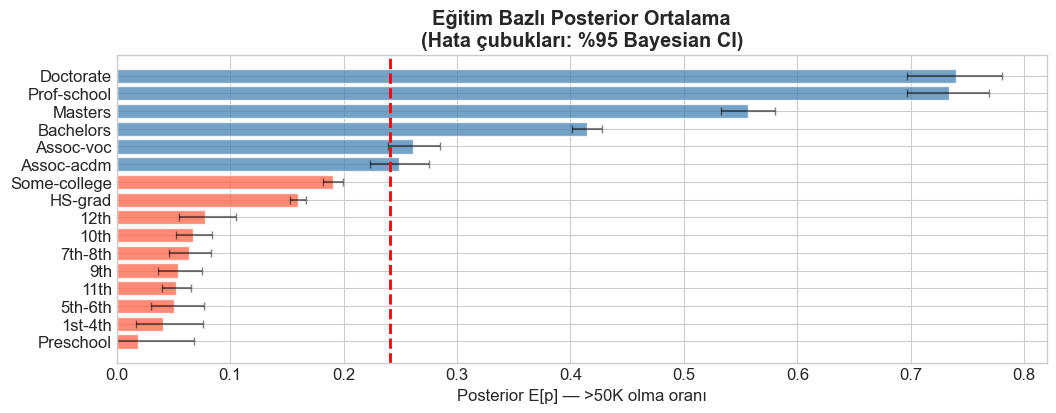

In [40]:
print('\n ===== Egzersiz 1: Beta: Prior Seçimi ve Etkisi =====')
print("\n Eğitim Seviyesine göre >50K olma oranını nedir? ")

egitim_ozet = adult.groupby('education')['yuksek_gelir'].agg(['sum','count']).reset_index()
egitim_ozet.columns = ['egitim','k','n']
# Posterior: Beta(1+k, 1+n-k) — her eğitim seviyesi
egitim_ozet['post_mean'] = (1 + egitim_ozet['k']) / (2 + egitim_ozet['n'])
egitim_ozet['post_ci_l'] = egitim_ozet.apply(
    lambda r: stats.beta(1+r['k'], 1+r['n']-r['k']).ppf(0.025), axis=1)
egitim_ozet['post_ci_u'] = egitim_ozet.apply(
    lambda r: stats.beta(1+r['k'], 1+r['n']-r['k']).ppf(0.975), axis=1)
egitim_ozet = egitim_ozet.sort_values('post_mean')

renkler_bar_egitim = ['tomato' if m < genel_oran else 'steelblue'
                      for m in egitim_ozet['post_mean']]
bars_egitim = plt.barh(egitim_ozet['egitim'], egitim_ozet['post_mean'],
                      color=renkler_bar_egitim, alpha=0.75, edgecolor='white')
plt.errorbar(egitim_ozet['post_mean'], egitim_ozet['egitim'],
            xerr=[egitim_ozet['post_mean']-egitim_ozet['post_ci_l'],
                  egitim_ozet['post_ci_u']-egitim_ozet['post_mean']],
            fmt='none', color='black', capsize=3, alpha=0.5)
plt.axvline(genel_oran, color='red', linestyle='--', linewidth=2,
           label=f'Genel oran={genel_oran:.3f}')
plt.xlabel('Posterior E[p] — >50K olma oranı')
plt.title('Eğitim Bazlı Posterior Ortalama\n(Hata çubukları: %95 Bayesian CI)', fontweight='bold')

print('n = 50 veri noktasına sahip bir grup için farklı priorlar nasıl etkiler? (Beta(1,1) vs Beta(2,10) vs Beta(10,2))')

print("")
n = 50
k = 15 # Diyelim ki 50 kisiden 15'i >50K kazaniyor
priorlar = [
    (1, 1, 'Uniform - Bilgisiz'),
    (2, 10, 'Pesimist - Basarisizlik Beklentisi'),
    (10, 2, 'İyimser - Basari Beklentisi')
]
for a, b, isim in priorlar:
    post_a = a + k
    post_b = b + (n - k)
    dist = stats.beta(post_a, post_b)
    
    mean = dist.mean()
    ci_l, ci_u = dist.ppf(0.025), dist.ppf(0.975)
    print(f"{isim:35} -> E[X]: {mean:.4f} | CI: [{ci_l:.3f}, {ci_u:.3f}]")
# Yorum: Veri az olduğu için (n=50), güçlü prior'lar (10,2 veya 2,10) sonucu 
# kendi taraflarına çeker. Veri çok olsaydı (örn n=5000) prior'ın etkisi kalmazdı.


In [41]:
print("\n=== E1b: A/B Testi Simülasyonu ===")
# Prior: Beta(1,1)
# Kontrol: n=1000, k=120 -> Posterior: Beta(1+120, 1+880) = Beta(121, 881)
# Test: n=1000, k=145 -> Posterior: Beta(1+145, 1+855) = Beta(146, 856)

kontrol_dist = stats.beta(121, 881)
test_dist = stats.beta(146, 856)

# Monte Carlo: Her iki dagilimdan 100.000 rastgele ornek cekistirip yaristiralim
sim_kontrol = kontrol_dist.rvs(100_000)
sim_test = test_dist.rvs(100_000)

kazanma_olasiligi = np.mean(sim_test > sim_kontrol)
print(f"P(Test CTR > Kontrol CTR) = %{kazanma_olasiligi * 100:.2f}")
# Yorum: %95'in üzerindeyse test grubunun daha iyi olduğundan emin olabiliriz.


=== E1b: A/B Testi Simülasyonu ===
P(Test CTR > Kontrol CTR) = %94.96


In [42]:
print("\n=== E1c: Beta(3, 7) Özellikleri ===")
a, b = 3, 7
E_X = a / (a + b)
Var_X = (a * b) / (((a + b)**2) * (a + b + 1))
print(f"E[X] = {E_X:.3f}")
print(f"Var(X) = {Var_X:.4f}")

# P(0.2 < X < 0.4) hesabi: CDF_buyuk - CDF_kucuk
prob = stats.beta(a, b).cdf(0.4) - stats.beta(a, b).cdf(0.2)
print(f"P(0.2 < X < 0.4) = {prob:.4f}")


=== E1c: Beta(3, 7) Özellikleri ===
E[X] = 0.300
Var(X) = 0.0191
P(0.2 < X < 0.4) = 0.5064



---
### E2 — Log-Normal: Dönüşüm ve Parametreler

a) Commerce verisi için:
   - `price`'ın ortalaması ve medyanı neden bu kadar farklı? Log-Normal bağlantısını kur  
   - σ (log-ölçekte) büyüdükçe ortalama-medyan farkı nasıl değişir?  
     σ = 0.5, 1, 2, 3 için `exp(mu+σ²/2)` ile `exp(mu)` oranını hesapla

b) Log-Normal vs Normal karşılaştırması:  
   Adult Income'daki `capital.gain` (≠ 0 olanlar) için:
   - Raw dağılım ve log-dönüşüm histogramını yan yana çiz  
   - QQ-Plot: raw vs log-dönüşüm — hangisi daha Normal?  

c) Log-Normal parametrelerini yorumla:  
   Bir ürün grubunda μ=4.5, σ=0.8 ise:
   - Medyan fiyat nedir?  
   - Ortalama fiyat nedir?  
   - Fiyatların %90'ı hangi değerin altında?  
   - Bir müşterinin 100'den ucuz ürün alma olasılığı nedir?

In [43]:
print("=== E2a: Log-Normal Şişme Etkisi ===")

# Sifir ve negatif fiyatlari cikar (log alamayiz)
ecom = ecom[ecom['price'] > 0].dropna(subset=['price'])

print(f'Yuklendi: {len(ecom):,} satir (price > 0)')
print(ecom['price'].describe().round(2))
print(f'Carpiklik: {stats.skew(ecom["price"]):.3f}  (saga carpik → Log-Normal adayi)')
print(f'Ortalama : {ecom["price"].mean():.2f}  |  Medyan: {ecom["price"].median():.2f}')
print(f'Ort > Medyan cok → saga carpik onaylandi')


mu = 5
for sigma in [0.5, 1, 2, 3]:
    medyan = np.exp(mu)
    ortalama = np.exp(mu + (sigma**2) / 2)
    print(f"σ={sigma} -> Medyan: {medyan:.1f}, Ortalama: {ortalama:.1f} | Oran (Ort/Med): {ortalama/medyan:.2f}")
# Yorum: σ (standart sapma) büyüdükçe, zenginlerin/pahalı ürünlerin (sağ kuyruk) etkisi
# o kadar abartılı hale gelir ki, ortalamayı astronomik seviyelere çıkarır.

=== E2a: Log-Normal Şişme Etkisi ===
Yuklendi: 1,589,331 satir (price > 0)
count    1589331.00
mean         190.63
std          260.78
min            0.02
25%           25.90
50%          104.14
75%          254.61
max        50925.90
Name: price, dtype: float64
Carpiklik: 8.493  (saga carpik → Log-Normal adayi)
Ortalama : 190.63  |  Medyan: 104.14
Ort > Medyan cok → saga carpik onaylandi
σ=0.5 -> Medyan: 148.4, Ortalama: 168.2 | Oran (Ort/Med): 1.13
σ=1 -> Medyan: 148.4, Ortalama: 244.7 | Oran (Ort/Med): 1.65
σ=2 -> Medyan: 148.4, Ortalama: 1096.6 | Oran (Ort/Med): 7.39
σ=3 -> Medyan: 148.4, Ortalama: 13359.7 | Oran (Ort/Med): 90.02



 B) Adult verisi içindeki sermaye kazançlarının log-normal dağılıma uygunluğunu inceleyelim. 
Yuklendi: 2,712 satir (capital.gain > 0)
Ortalama : 12938.54  |  Medyan: 7298.00
Ort > Medyan cok → saga carpik onaylandi
Haftalik calisma saati: n=32,561
Ort=40.44, Medyan=40.00, Std=12.35
Carpiklik=0.228

Normal   : μ=12938.54, σ=22391.28  | AIC=62029.4
Log-Normal: μ=8.8198, σ=1.0153 | AIC=55621.6
Kazanan  : Log-Normal (dusuk AIC)


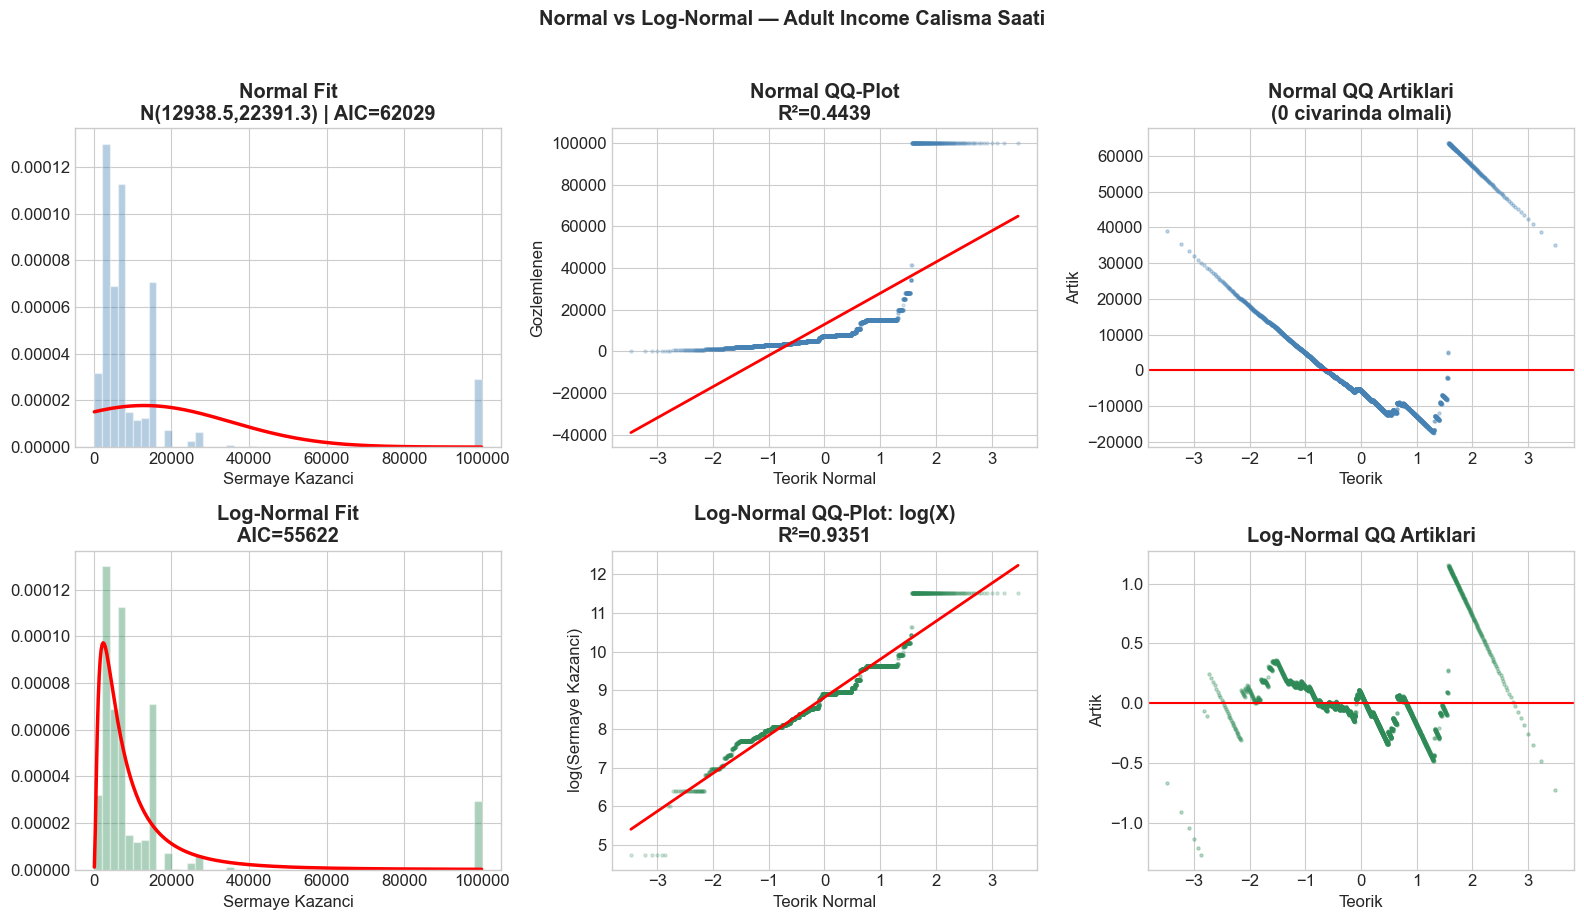


Karsilastirma: Normal R²=0.4439 vs Log-Normal R²=0.9351
Kazanan (yuksek R²): Log-Normal


In [44]:
print("\n B) Adult verisi içindeki sermaye kazançlarının log-normal dağılıma uygunluğunu inceleyelim. ")
# Sifir ve negatif fiyatlari cikar (log alamayiz)
gain = adult[adult['capital.gain'] > 0]['capital.gain'].values

print(f'Yuklendi: {len(gain):,} satir (capital.gain > 0)')
print(f'Ortalama : {gain.mean():.2f}  |  Medyan: {np.median(gain):.2f}')
print(f'Ort > Medyan cok → saga carpik onaylandi')

print(f'Haftalik calisma saati: n={len(saat):,}')
print(f'Ort={saat.mean():.2f}, Medyan={np.median(saat):.2f}, Std={saat.std():.2f}')
print(f'Carpiklik={stats.skew(saat):.3f}')

# MLE: Normal
mu_n, sigma_n = stats.norm.fit(gain)
ll_n = stats.norm(mu_n, sigma_n).logpdf(gain).sum()
aic_n = 2*2 - 2*ll_n

# MLE: Log-Normal
s_ln, loc_ln2, scale_ln2 = stats.lognorm.fit(gain, floc=0)
ll_ln = stats.lognorm(s_ln, loc_ln2, scale_ln2).logpdf(gain).sum()
aic_ln = 2*2 - 2*ll_ln

print(f'\nNormal   : μ={mu_n:.2f}, σ={sigma_n:.2f}  | AIC={aic_n:.1f}')
print(f'Log-Normal: μ={np.log(scale_ln2):.4f}, σ={s_ln:.4f} | AIC={aic_ln:.1f}')
print(f'Kazanan  : {"Log-Normal" if aic_ln < aic_n else "Normal"} (dusuk AIC)')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Ust sira: Normal fit
# Histogram + fit
ax = axes[0][0]
ax.hist(gain, bins=50, density=True, color='steelblue', alpha=0.4, edgecolor='white')
x_r = np.linspace(gain.min(), gain.max(), 400)
ax.plot(x_r, stats.norm.pdf(x_r, mu_n, sigma_n), 'r-', linewidth=2.5)
ax.set_title(f'Normal Fit\nN({mu_n:.1f},{sigma_n:.1f}) | AIC={aic_n:.0f}', fontweight='bold')
ax.set_xlabel('Sermaye Kazanci')

# QQ-Plot: Normal
ax = axes[0][1]
(tq, gq), (slope, intercept, r_n) = stats.probplot(gain, dist='norm')
ax.scatter(tq, gq, alpha=0.2, s=5, color='steelblue')
ax.plot([tq.min(), tq.max()],
        [slope*tq.min()+intercept, slope*tq.max()+intercept], 'r-', linewidth=2)
ax.set_title(f'Normal QQ-Plot\nR²={r_n**2:.4f}', fontweight='bold')
ax.set_xlabel('Teorik Normal')
ax.set_ylabel('Gozlemlenen')

# Residuals: Normal
ax = axes[0][2]
resid_n = gq - (slope*tq + intercept)
ax.scatter(tq, resid_n, alpha=0.3, s=5, color='steelblue')
ax.axhline(0, color='red', linewidth=1.5)
ax.set_title('Normal QQ Artiklari\n(0 civarinda olmali)', fontweight='bold')
ax.set_xlabel('Teorik')
ax.set_ylabel('Artik')

# Alt sira: Log-Normal fit
ax = axes[1][0]
ax.hist(gain, bins=50, density=True, color='seagreen', alpha=0.4, edgecolor='white')
lndist2 = stats.lognorm(s_ln, loc=0, scale=scale_ln2)
ax.plot(x_r, lndist2.pdf(x_r), 'r-', linewidth=2.5)
ax.set_title(f'Log-Normal Fit\nAIC={aic_ln:.0f}', fontweight='bold')
ax.set_xlabel('Sermaye Kazanci')

# QQ-Plot: Log-Normal = log(X) Normal mi?
ax = axes[1][1]
log_gain = np.log(gain)
(tq2, gq2), (slope2, intercept2, r_ln) = stats.probplot(log_gain, dist='norm')
ax.scatter(tq2, gq2, alpha=0.2, s=5, color='seagreen')
ax.plot([tq2.min(), tq2.max()],
        [slope2*tq2.min()+intercept2, slope2*tq2.max()+intercept2], 'r-', linewidth=2)
ax.set_title(f'Log-Normal QQ-Plot: log(X)\nR²={r_ln**2:.4f}', fontweight='bold')
ax.set_xlabel('Teorik Normal')
ax.set_ylabel('log(Sermaye Kazanci)')

ax = axes[1][2]
resid_ln = gq2 - (slope2*tq2 + intercept2)
ax.scatter(tq2, resid_ln, alpha=0.3, s=5, color='seagreen')
ax.axhline(0, color='red', linewidth=1.5)
ax.set_title('Log-Normal QQ Artiklari', fontweight='bold')
ax.set_xlabel('Teorik')
ax.set_ylabel('Artik')

plt.suptitle('Normal vs Log-Normal — Adult Income Calisma Saati', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nKarsilastirma: Normal R²={r_n**2:.4f} vs Log-Normal R²={r_ln**2:.4f}')
print(f'Kazanan (yuksek R²): {"Normal" if r_n**2 > r_ln**2 else "Log-Normal"}')


In [45]:
print("\n=== E2c: Fiyat Tahminleri (μ=4.5, σ=0.8) ===")
mu = 4.5
sigma = 0.8
dist = stats.lognorm(s=sigma, scale=np.exp(mu))

print(f"Medyan fiyat: {np.exp(mu):.2f} $")
print(f"Ortalama fiyat: {np.exp(mu + (sigma**2)/2):.2f} $")
print(f"%90 fiyatın altı: {dist.ppf(0.90):.2f} $")
print(f"100$'dan ucuz olma olasılığı: %{dist.cdf(100)*100:.2f}")


=== E2c: Fiyat Tahminleri (μ=4.5, σ=0.8) ===
Medyan fiyat: 90.02 $
Ortalama fiyat: 123.97 $
%90 fiyatın altı: 250.95 $
100$'dan ucuz olma olasılığı: %55.23


---
### E3 — SQL: Bayesian + Log-Normal Birleşik Analiz

a) SQL'de şunu yap: Adult Income'da her `workclass` için:
   - `n`, `k`, `alpha_post`, `beta_post`, `post_mean` hesapla  
   - `alpha_post / (alpha_post + beta_post + 1)` ile yaklaşık posterior varyansı hesapla  
   - n büyük gruplarda varyans küçülüyor mu? Tabloyla göster

b) Commerce verisinde SQL ile:
   - `brand` bazında Log-Normal μ ve σ tahmin et  
   - En yüksek μ'ya sahip 5 marka (en pahalı medyan fiyat)  
   - En yüksek σ'ya sahip 5 marka (en değişken fiyat)

c) SQL'de Log-Normal yüzdelik hesabı:  
   `PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY price)` ile empirik %90 yüzdeliği bul.  
   `EXP(AVG(LN(price)) + 1.282 * STDDEV_POP(LN(price)))` ile teorik tahmin yap.  
   (Not: 1.282 = Normal dağılımın %90 yüzdeliği = `qnorm(0.90)`)  
   İkisini karşılaştır — kategori bazında kim daha doğru?

In [47]:
work_sql = con.execute(
"""
    SELECT 
    TRIM(workclass) AS workclass,
    COUNT(*) AS n,
    -- a ve b'yi hesaplıyoruz (Prior Beta(1,1))
    1 + SUM(CASE WHEN income='>50K' THEN 1 ELSE 0 END) AS alpha_post,
    1 + COUNT(*) - SUM(CASE WHEN income='>50K' THEN 1 ELSE 0 END) AS beta_post,
    
    -- Varyans Formülü: (a*b) / ((a+b)^2 * (a+b+1))
    ROUND(
        (alpha_post * beta_post * 1.0) / 
        (POWER(alpha_post + beta_post, 2) * (alpha_post + beta_post + 1)), 
    6) AS post_varyans
FROM adult_tbl
WHERE TRIM(workclass) != '?'
GROUP BY workclass
ORDER BY n DESC;
""").df()

print("\n=== E3a: Workclass Bazlı Posterior Varyans ===")
print(work_sql.to_string(index=False))

wealth_sql = con.execute(
"""
SELECT 
    brand,
    COUNT(*) as satis_sayisi,
    ROUND(AVG(LN(price)), 3) AS mu,
    ROUND(STDDEV_POP(LN(price)), 3) AS sigma,
    ROUND(EXP(AVG(LN(price))), 2) AS medyan_fiyat -- exp(mu) = medyan
FROM ecom_tbl
WHERE brand IS NOT NULL AND price > 0
GROUP BY brand
HAVING COUNT(*) > 500
ORDER BY medyan_fiyat DESC
LIMIT 5;
""").df()

print("\n=== E3b: En Pahalı 5 Marka (Medyan Fiyat) ===")
print(wealth_sql.to_string(index=False))


=== E3a: Workclass Bazlı Posterior Varyans ===
       workclass     n  alpha_post  beta_post  post_varyans
         Private 22696      4964.0    17734.0      0.000008
Self-emp-not-inc  2541       725.0     1818.0      0.000080
       Local-gov  2093       618.0     1477.0      0.000099
       State-gov  1298       354.0      946.0      0.000152
    Self-emp-inc  1116       623.0      495.0      0.000220
     Federal-gov   960       372.0      590.0      0.000246
     Without-pay    14         1.0       15.0      0.003447
    Never-worked     7         1.0        8.0      0.009877

=== E3b: En Pahalı 5 Marka (Medyan Fiyat) ===
 brand  satis_sayisi    mu  sigma  medyan_fiyat
garmin           785 6.429  0.605        619.46
 dyson           624 6.260  0.372        523.13
 apple         70650 6.256  0.827        521.35
lenovo         19583 6.149  0.573        468.26
 kaabo           668 6.087  0.467        440.22


---
### E4 — Gerçek Hayat: Hangi Dağılım?

Aşağıdaki değişkenler için hangi dağılımın uygun olduğuna karar ver.  
QQ-Plot, AIC ve çarpıklık testini kullanarak gerekçelendir:

a) `adult['hours.per.week']` — haftalık çalışma saati  
   Adaylar: Normal, Log-Normal, Gamma

b) `adult['age']` — yaş  
   Adaylar: Normal, Uniform, Log-Normal

c) `ecom['price']` — sadece `electronics` kategorisi  
   Adaylar: Log-Normal, Gamma, Weibull (`stats.weibull_min.fit(data, floc=0)`), Uniform

Her dağılım için:
1. MLE fit yap
2. QQ-Plot çiz
3. AIC hesapla
4. Kazanan dağılımı seç ve sezgisel açıkla



=== E4: Herçek Hayatta Hangi Dağılım? ===
=== Model Karsilastirmasi (n=32,561) ===
Dagilim            k         logL          AIC          BIC Parametreler
Exponential        1   -153028.77    306059.54    306067.93  λ=0.0247
Gamma              2   -131404.09    262812.19    262828.97  α=8.006, β=5.051
Log-Normal         2   -135570.37    271144.74    271161.52  μ=3.636, σ=0.410

→ En iyi AIC: Gamma  (α=8.006, β=5.051)


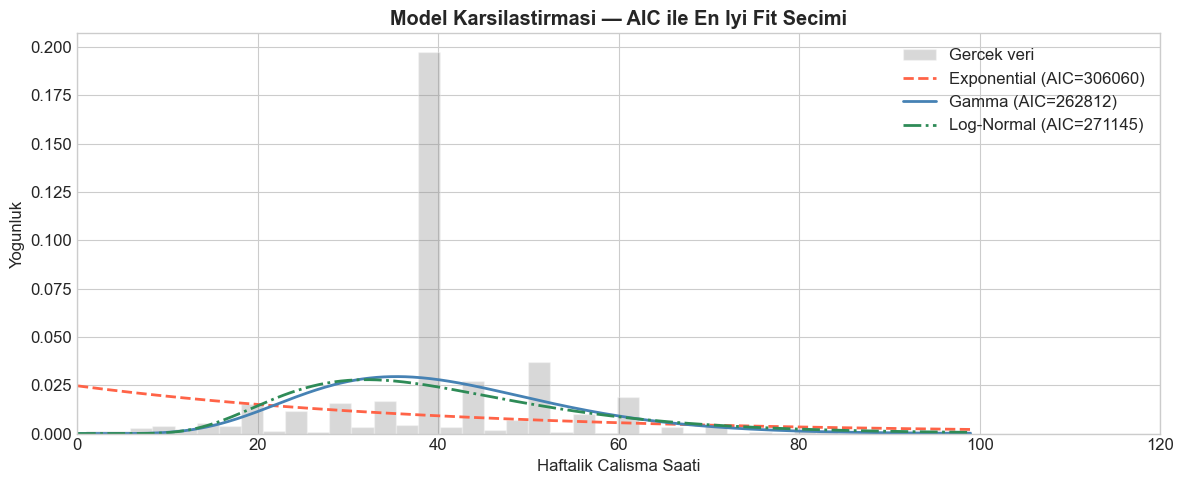

In [ ]:
print("\n=== E4a: Herçek Hayatta Hangi Dağılım? ===")

veri = adult['hours.per.week'].values
n_saat    = len(veri)


# Saat için
modeller = {}

# 1. Exponential
loc_e, scale_e = stats.expon.fit(veri, floc=0)
ll_e = stats.expon(loc=loc_e, scale=scale_e).logpdf(veri).sum()
modeller['Exponential'] = {'params': 1, 'logL': ll_e,
                           'paramStr': f'λ={1/scale_e:.4f}'}

# 2. Gamma
a_g, loc_g, scale_g = stats.gamma.fit(veri, floc=0)
ll_g = stats.gamma(a=a_g, loc=loc_g, scale=scale_g).logpdf(veri).sum()
modeller['Gamma'] = {'params': 2, 'logL': ll_g,
                     'paramStr': f'α={a_g:.3f}, β={scale_g:.3f}'}

# 3. Log-Normal (log(X) ~ Normal)
mu_ln, sigma_ln = stats.norm.fit(np.log(veri))
ll_ln = stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)).logpdf(veri).sum()
modeller['Log-Normal'] = {'params': 2, 'logL': ll_ln,
                          'paramStr': f'μ={mu_ln:.3f}, σ={sigma_ln:.3f}'}

# AIC ve BIC hesabi
print(f'=== Model Karsilastirmasi (n={n_saat:,}) ===')
print(f'{"Dagilim":<15} {"k":>4} {"logL":>12} {"AIC":>12} {"BIC":>12} {"Parametreler"}')
sonuclar = []
for ad, m in modeller.items():
    k   = m['params']
    ll  = m['logL']
    aic = 2*k - 2*ll
    bic = k * np.log(n_saat) - 2*ll
    sonuclar.append({'ad': ad, 'k': k, 'logL': ll, 'AIC': aic, 'BIC': bic,
                     'params': m['paramStr']})
    print(f'{ad:<15} {k:>4} {ll:>12.2f} {aic:>12.2f} {bic:>12.2f}  {m["paramStr"]}')

en_iyi = min(sonuclar, key=lambda x: x['AIC'])
print(f'\n→ En iyi AIC: {en_iyi["ad"]}  ({en_iyi["params"]})')

# Gorsel karsilastirma
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(veri, bins=40, density=True, color='gray', alpha=0.3,
        edgecolor='white', label='Gercek veri')
x_r = np.linspace(0.1, veri.max(), 500)

dist_cizim = [
    ('Exponential', stats.expon(scale=scale_e), 'tomato',       '--'),
    ('Gamma',       stats.gamma(a=a_g, scale=scale_g), 'steelblue', '-'),
    ('Log-Normal',  stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)), 'seagreen', '-.'),
]

for ad, dist, renk, ls in dist_cizim:
    row = next(r for r in sonuclar if r['ad']==ad)
    ax.plot(x_r, dist.pdf(x_r), color=renk, linewidth=2, linestyle=ls,
            label=f'{ad} (AIC={row["AIC"]:.0f})')

ax.set_xlim(0, 120)
ax.set_xlabel('Haftalik Calisma Saati')
ax.set_ylabel('Yogunluk')
ax.set_title('Model Karsilastirmasi — AIC ile En Iyi Fit Secimi', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()



=== E4b: Herçek Hayatta Hangi Dağılım? ===
=== Model Karsilastirmasi (n=32,561) ===
Dagilim            k         logL          AIC          BIC Parametreler
Normal             2   -131284.70    262573.40    262590.18  μ=38.582, σ=13.640
Uniform            2   -139701.65    279407.30    279424.08  a=17.0, b=90.0
Log-Normal         2   -129842.94    259689.89    259706.67  μ=3.589, σ=0.360

→ En iyi AIC: Log-Normal  (μ=3.589, σ=0.360)


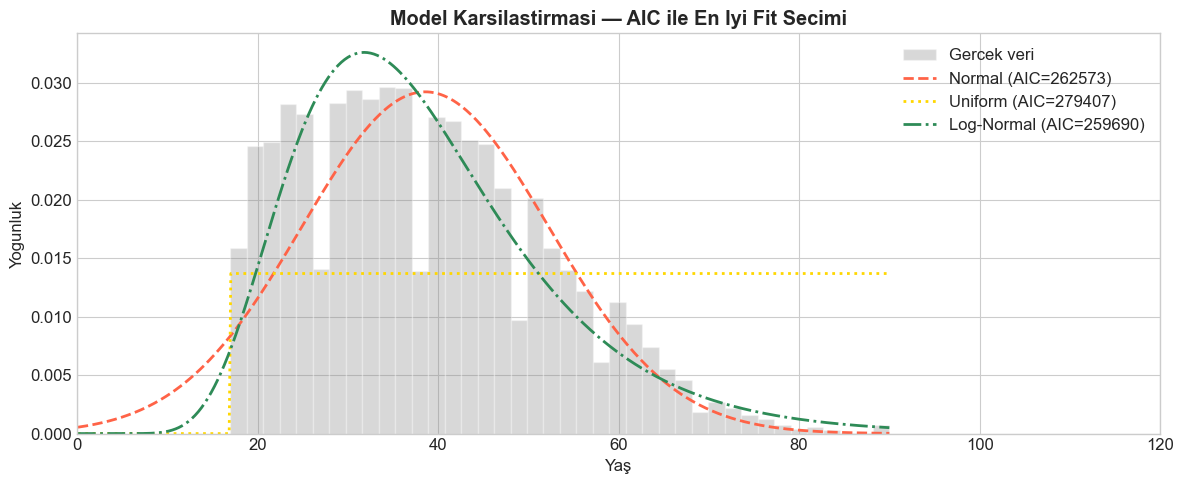

In [59]:
print("\n=== E4b: Herçek Hayatta Hangi Dağılım? ===")

veri = adult['age'].values
n_yas     = len(veri)


# Saat için
modeller = {}

# 1. Normal
loc_n, scale_n = stats.norm.fit(veri)
ll_n = stats.norm(loc=loc_n, scale=scale_n).logpdf(veri).sum()
modeller['Normal'] = {'params': 2, 'logL': ll_n,
                      'paramStr': f'μ={loc_n:.3f}, σ={scale_n:.3f}'}

# 2. Uniform
a_u, b_u = veri.min(), veri.max()
scale_u = b_u - a_u
ll_u = stats.uniform(loc=a_u, scale=scale_u).logpdf(veri).sum()
modeller['Uniform'] = {'params': 2, 'logL': ll_u,
                       'paramStr': f'a={a_u:.1f}, b={b_u:.1f}'}

# 3. Log-Normal (log(X) ~ Normal)
mu_ln, sigma_ln = stats.norm.fit(np.log(veri))
ll_ln = stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)).logpdf(veri).sum()
modeller['Log-Normal'] = {'params': 2, 'logL': ll_ln,
                          'paramStr': f'μ={mu_ln:.3f}, σ={sigma_ln:.3f}'}


# AIC ve BIC hesabi
print(f'=== Model Karsilastirmasi (n={n_saat:,}) ===')
print(f'{"Dagilim":<15} {"k":>4} {"logL":>12} {"AIC":>12} {"BIC":>12} {"Parametreler"}')
sonuclar = []
for ad, m in modeller.items():
    k   = m['params']
    ll  = m['logL']
    aic = 2*k - 2*ll
    bic = k * np.log(n_saat) - 2*ll
    sonuclar.append({'ad': ad, 'k': k, 'logL': ll, 'AIC': aic, 'BIC': bic,
                     'params': m['paramStr']})
    print(f'{ad:<15} {k:>4} {ll:>12.2f} {aic:>12.2f} {bic:>12.2f}  {m["paramStr"]}')

en_iyi = min(sonuclar, key=lambda x: x['AIC'])
print(f'\n→ En iyi AIC: {en_iyi["ad"]}  ({en_iyi["params"]})')

# Gorsel karsilastirma
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(veri, bins=40, density=True, color='gray', alpha=0.3,
        edgecolor='white', label='Gercek veri')
x_r = np.linspace(0.1, veri.max(), 500)

dist_cizim = [
    ('Normal', stats.norm(loc=loc_n, scale=scale_n), 'tomato',       '--'),
    ('Uniform',     stats.uniform(loc=a_u, scale=scale_u), 'gold', ':'),
    ('Log-Normal',  stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)), 'seagreen', '-.'),
]

for ad, dist, renk, ls in dist_cizim:
    row = next(r for r in sonuclar if r['ad']==ad)
    ax.plot(x_r, dist.pdf(x_r), color=renk, linewidth=2, linestyle=ls,
            label=f'{ad} (AIC={row["AIC"]:.0f})')

ax.set_xlim(0, 120)
ax.set_xlabel('Yaş')
ax.set_ylabel('Yogunluk')
ax.set_title('Model Karsilastirmasi — AIC ile En Iyi Fit Secimi', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()



=== E4c: Herçek Hayatta Hangi Dağılım? ===
=== Model Karsilastirmasi (n=549,038) ===
Dagilim            k         logL          AIC          BIC Parametreler
Weibull            2  -3623253.99   7246511.97   7246534.40  c=0.987, scale=268.708
Gamma              2  -3623335.63   7246675.26   7246697.69  α=1.001, β=269.946
Log-Normal         2  -3663789.96   7327583.91   7327606.34  μ=5.023, σ=1.260
Uniform            2  -5950541.04  11901086.09  11901108.52  a=0.2, b=50925.9

→ En iyi AIC: Weibull  (c=0.987, scale=268.708)


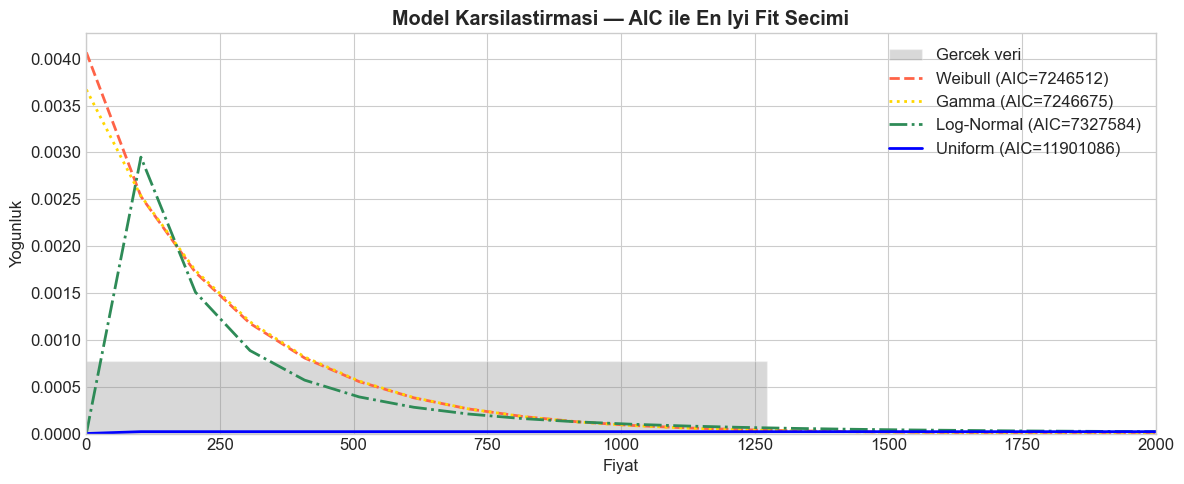

In [75]:
print("\n=== E4c: Herçek Hayatta Hangi Dağılım? ===")

electric = ecom.loc[
    ecom['category_code'].str.split('.').str[0] == 'electronics',
    'price'
].values
veri = electric
n     = len(veri)


# Fiyat için
modeller = {}

# 1. Weibull
c_w, loc_w, scale_w = stats.weibull_min.fit(veri, floc=0)
ll_w = stats.weibull_min(c=c_w, loc=loc_w, scale=scale_w).logpdf(veri).sum()
modeller['Weibull'] = {'params': 2, 'logL': ll_w,
                       'paramStr': f'c={c_w:.3f}, scale={scale_w:.3f}'}

# 2. Gamma
a_g, loc_g, scale_g = stats.gamma.fit(veri, floc=0)
ll_g = stats.gamma(a=a_g, loc=loc_g, scale=scale_g).logpdf(veri).sum()
modeller['Gamma'] = {'params': 2, 'logL': ll_g,
                     'paramStr': f'α={a_g:.3f}, β={scale_g:.3f}'}

# 3. Log-Normal (log(X) ~ Normal)
mu_ln, sigma_ln = stats.norm.fit(np.log(veri))
ll_ln = stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)).logpdf(veri).sum()
modeller['Log-Normal'] = {'params': 2, 'logL': ll_ln,
                          'paramStr': f'μ={mu_ln:.3f}, σ={sigma_ln:.3f}'}

# 4. Uniform
a_u, b_u = veri.min(), veri.max()
scale_u = b_u - a_u
ll_u = stats.uniform(loc=a_u, scale=scale_u).logpdf(veri).sum()
modeller['Uniform'] = {'params': 2, 'logL': ll_u,
                       'paramStr': f'a={a_u:.1f}, b={b_u:.1f}'}


# AIC ve BIC hesabi
print(f'=== Model Karsilastirmasi (n={n:,}) ===')
print(f'{"Dagilim":<15} {"k":>4} {"logL":>12} {"AIC":>12} {"BIC":>12} {"Parametreler"}')
sonuclar = []
for ad, m in modeller.items():
    k   = m['params']
    ll  = m['logL']
    aic = 2*k - 2*ll
    bic = k * np.log(n) - 2*ll
    sonuclar.append({'ad': ad, 'k': k, 'logL': ll, 'AIC': aic, 'BIC': bic,
                     'params': m['paramStr']})
    print(f'{ad:<15} {k:>4} {ll:>12.2f} {aic:>12.2f} {bic:>12.2f}  {m["paramStr"]}')

en_iyi = min(sonuclar, key=lambda x: x['AIC'])
print(f'\n→ En iyi AIC: {en_iyi["ad"]}  ({en_iyi["params"]})')

# Gorsel karsilastirma
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(veri, bins=40, density=True, color='gray', alpha=0.3,
        edgecolor='white', label='Gercek veri')
x_r = np.linspace(0.1, veri.max(), 500)

dist_cizim = [
    ('Weibull', stats.weibull_min(c=c_w, loc=loc_w, scale=scale_w), 'tomato',       '--'),
    ('Gamma',     stats.gamma(a=a_g, loc=loc_g, scale=scale_g), 'gold', ':'),
    ('Log-Normal',  stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)), 'seagreen', '-.'),
    ('Uniform',     stats.uniform(loc=a_u, scale=scale_u), 'blue', '-'),
]

for ad, dist, renk, ls in dist_cizim:
    row = next(r for r in sonuclar if r['ad']==ad)
    ax.plot(x_r, dist.pdf(x_r), color=renk, linewidth=2, linestyle=ls,
            label=f'{ad} (AIC={row["AIC"]:.0f})')

ax.set_xlim(0, 2000)
ax.set_xlabel('Fiyat')
ax.set_ylabel('Yogunluk')
ax.set_title('Model Karsilastirmasi — AIC ile En Iyi Fit Secimi', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Chan](https://probability4datascience.com) | Ch. 4.6–4.7 | Beta ve Log-Normal teorisi |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 17–18 | Beta ve Bayesian bağlantısı |
| [Bayesian Methods for Hackers](https://github.com/CamDavidsonPilon) | Ch. 1–2 | Beta A/B testi |